In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = '/Users/nisitha/Development/Source/python/heroveird/assignment/28Mar_12Apr/Datasets/'
df_application = pd.read_csv(path + 'applications.csv', dtype={'Rejection_Reason': str})
df_branches = pd.read_csv(path + 'branches.csv')
df_customers = pd.read_csv(path + 'customers.csv')
df_defaults = pd.read_csv(path + 'defaults.csv')
df_loans = pd.read_csv(path + 'loans.csv')
df_transactions = pd.read_csv(path + 'transactions.csv')

## 1. Data Quality and Preparation
### > Validate and clean the datasets.
### > Check for missing values, duplicate entries, and inconsistent data.
### > Standardize date formats and remove irrelevant columns.
### > Handle outliers in numeric columns like Loan_Amount, Interest_Rate, andDefault_Amount.

In [3]:
# Store dataframes in a dictionary for easy iteration
dataframes = {
    "df_application": df_application,
    "df_branches": df_branches,
    "df_customers": df_customers,
    "df_defaults": df_defaults,
    "df_loans": df_loans,
    "df_transactions": df_transactions,
}
dataframes

{'df_application':       Application_ID  Loan_ID Customer_ID Application_Date Approval_Date  \
 0            A000001  L000001     C000001       2022-05-11    2020-10-02   
 1            A000002  L000002     C000002       2022-03-18    2022-11-29   
 2            A000003  L000003     C000003       2022-01-17    2023-07-01   
 3            A000004  L000004     C000004       2019-03-09    2024-08-30   
 4            A000005  L000005     C000005       2024-07-18    2020-03-18   
 ...              ...      ...         ...              ...           ...   
 82595        A082596      NaN     C016646       2021-08-19           NaN   
 82596        A082597      NaN     C010571       2021-01-30           NaN   
 82597        A082598      NaN     C006731       2023-04-17           NaN   
 82598        A082599      NaN     C008140       2021-04-22           NaN   
 82599        A082600      NaN     C060782       2023-05-28           NaN   
 
           Loan_Purpose Source_Channel  Processing_Fee A

In [9]:

for name, df in dataframes.items():
    print(f"--- Validating DataFrame Started for: {name} ---")
    print("Shape:", df.shape)
    print("\nInfo:")
    df.info()
    print("\nMissing values:")
    print(df.isnull().sum())
    print("\nDuplicate rows:")
    print(df.duplicated().sum())
    
    primary_column = ''
    if name == "df_application":
        primary_column = 'Application_ID'
    elif name == "df_branches":
        primary_column = 'Branch_ID'
    elif name == "df_customers":
        primary_column = 'Customer_ID'
    elif name == "df_defaults":
        primary_column = 'Default_ID'
    elif name == "df_loans":
        primary_column = 'Loan_ID'
    elif name == "df_transactions":
        primary_column = 'Transaction_ID'

    print(f'\nUnique {primary_column} values:')
    display(df[primary_column].nunique())
    print('Total rows:', len(df))

    print(f"--- Validation Completed for: {name} ---\n\n")

--- Validating DataFrame Started for: df_application ---
Shape: (82600, 10)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82600 entries, 0 to 82599
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Application_ID    82600 non-null  object
 1   Loan_ID           70000 non-null  object
 2   Customer_ID       82600 non-null  object
 3   Application_Date  82600 non-null  object
 4   Approval_Date     70000 non-null  object
 5   Loan_Purpose      82600 non-null  object
 6   Source_Channel    82600 non-null  object
 7   Processing_Fee    82600 non-null  int64 
 8   Approval_Status   82600 non-null  object
 9   Rejection_Reason  12600 non-null  object
dtypes: int64(1), object(9)
memory usage: 6.3+ MB

Missing values:
Application_ID          0
Loan_ID             12600
Customer_ID             0
Application_Date        0
Approval_Date       12600
Loan_Purpose            0
Source_Channel          0
Process

82600

Total rows: 82600
--- Validation Completed for: df_application ---


--- Validating DataFrame Started for: df_branches ---
Shape: (50, 9)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Branch_ID                   50 non-null     object
 1   Branch_Name                 50 non-null     object
 2   Region                      50 non-null     object
 3   Total_Customers             50 non-null     int64 
 4   Total_Active_Loans          50 non-null     int64 
 5   Delinquent_Loans            50 non-null     int64 
 6   Loan_Disbursement_Amount    50 non-null     int64 
 7   Avg_Processing_Time         50 non-null     int64 
 8   Relationship_Manager_Count  50 non-null     int64 
dtypes: int64(6), object(3)
memory usage: 3.6+ KB

Missing values:
Branch_ID                     0
Branch_Name                   0
Region

50

Total rows: 50
--- Validation Completed for: df_branches ---


--- Validating DataFrame Started for: df_customers ---
Shape: (70000, 14)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Customer_ID              70000 non-null  object
 1   Full_Name                70000 non-null  object
 2   Contact_Number           70000 non-null  int64 
 3   Email                    70000 non-null  object
 4   Address                  70000 non-null  object
 5   Age                      70000 non-null  int64 
 6   Gender                   70000 non-null  object
 7   Marital_Status           70000 non-null  object
 8   Employment_Status        70000 non-null  object
 9   Annual_Income            70000 non-null  int64 
 10  Credit_Score             70000 non-null  int64 
 11  Region                   70000 non-null  object
 12  

...

Total rows: 9000
--- Validation Completed for: df_defaults ---


--- Validating DataFrame Started for: df_loans ---
Shape: (90000, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Loan_ID               90000 non-null  object 
 1   Customer_ID           90000 non-null  object 
 2   Loan_Amount           90000 non-null  int64  
 3   Interest_Rate         90000 non-null  float64
 4   Loan_Term             90000 non-null  int64  
 5   Disbursal_Date        90000 non-null  object 
 6   Repayment_Start_Date  90000 non-null  object 
 7   Repayment_End_Date    90000 non-null  object 
 8   Loan_Status           90000 non-null  object 
 9   Overdue_Amount        90000 non-null  int64  
 10  EMI_Amount            90000 non-null  int64  
 11  Collateral_Details    59806 non-null  object 
dtypes: float64(1), int64(4), objec

90000

Total rows: 90000
--- Validation Completed for: df_loans ---


--- Validating DataFrame Started for: df_transactions ---
Shape: (495000, 9)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495000 entries, 0 to 494999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Transaction_ID     495000 non-null  object
 1   Loan_ID            495000 non-null  object
 2   Customer_ID        495000 non-null  object
 3   Transaction_Date   495000 non-null  object
 4   Payment_Type       495000 non-null  object
 5   Amount             495000 non-null  int64 
 6   Overdue_Fee        495000 non-null  int64 
 7   Remaining_Balance  495000 non-null  int64 
 8   Mode_of_Payment    495000 non-null  object
dtypes: int64(3), object(6)
memory usage: 34.0+ MB

Missing values:
Transaction_ID       0
Loan_ID              0
Customer_ID          0
Transaction_Date     0
Payment_Type         0
Amount               0
Overdue_F

495000

Total rows: 495000
--- Validation Completed for: df_transactions ---




In [10]:
# Standardize date formats for df_application
df_application['Application_Date'] = pd.to_datetime(df_application['Application_Date'])
df_application['Approval_Date'] = pd.to_datetime(df_application['Approval_Date'])

# Remove 'Rejection_Reason' column due to high missing values
df_application = df_application.drop(columns=['Rejection_Reason'])

print('--- df_application after cleaning ---')
display(df_application.head())
df_application.info()

--- df_application after cleaning ---


,Application_ID,Loan_ID,Customer_ID,Application_Date,Approval_Date,Loan_Purpose,Source_Channel,Processing_Fee,Approval_Status
0,A000001,L000001,C000001,2022-05-11,2020-10-02,Business,Agent,6427,Approved
1,A000002,L000002,C000002,2022-03-18,2022-11-29,Education,Online,8605,Approved
2,A000003,L000003,C000003,2022-01-17,2023-07-01,Business,Online,1450,Approved
3,A000004,L000004,C000004,2019-03-09,2024-08-30,Home Renovation,Agent,8171,Approved
4,A000005,L000005,C000005,2024-07-18,2020-03-18,Education,Branch,4931,Approved


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82600 entries, 0 to 82599
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Application_ID    82600 non-null  object        
 1   Loan_ID           70000 non-null  object        
 2   Customer_ID       82600 non-null  object        
 3   Application_Date  82600 non-null  datetime64[ns]
 4   Approval_Date     70000 non-null  datetime64[ns]
 5   Loan_Purpose      82600 non-null  object        
 6   Source_Channel    82600 non-null  object        
 7   Processing_Fee    82600 non-null  int64         
 8   Approval_Status   82600 non-null  object        
dtypes: datetime64[ns](2), int64(1), object(6)
memory usage: 5.7+ MB


In [11]:
# Standardize date formats for df_defaults
df_defaults['Default_Date'] = pd.to_datetime(df_defaults['Default_Date'])

display(df_defaults.head())
df_defaults.info()

,Default_ID,Loan_ID,Customer_ID,Default_Date,Default_Amount,Default_Reason,Recovery_Status,Recovery_Amount,Legal_Action
0,D000001,L007312,C007312,2022-07-20,94480,Job Loss,Full,30360,Yes
1,D000002,L028234,C028234,2023-09-23,10912,Job Loss,Partial,0,Yes
2,D000003,L008319,C008319,2024-08-04,73711,Other,NaN,9866,Yes
3,D000004,L046668,C046668,2021-10-16,48955,Other,NaN,0,Yes
4,D000005,L082934,C082934,2024-10-07,56952,Medical Emergency,NaN,0,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Default_ID       9000 non-null   object        
 1   Loan_ID          9000 non-null   object        
 2   Customer_ID      9000 non-null   object        
 3   Default_Date     9000 non-null   datetime64[ns]
 4   Default_Amount   9000 non-null   int64         
 5   Default_Reason   9000 non-null   object        
 6   Recovery_Status  6015 non-null   object        
 7   Recovery_Amount  9000 non-null   int64         
 8   Legal_Action     9000 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 632.9+ KB


In [12]:
# Standardize date formats for df_loans
df_loans['Disbursal_Date'] = pd.to_datetime(df_loans['Disbursal_Date'])
df_loans['Repayment_Start_Date'] = pd.to_datetime(df_loans['Repayment_Start_Date'])
df_loans['Repayment_End_Date'] = pd.to_datetime(df_loans['Repayment_End_Date'])

# Remove 'Collateral_Details' column due to high missing values
df_loans = df_loans.drop(columns=['Collateral_Details'])

print('\n--- df_loans after cleaning ---')
display(df_loans.head())
df_loans.info()


--- df_loans after cleaning ---


,Loan_ID,Customer_ID,Loan_Amount,Interest_Rate,Loan_Term,Disbursal_Date,Repayment_Start_Date,Repayment_End_Date,Loan_Status,Overdue_Amount,EMI_Amount
0,L000001,C045929,4030468,8.45,24,2023-03-25,2023-04-25,2025-03-25,Active,0,18668
1,L000002,C038991,3498647,11.90,48,2023-10-23,2023-11-23,2027-10-23,Closed,44003,36012
2,L000003,C046662,4871438,9.74,24,2024-07-30,2024-08-30,2026-07-30,Overdue,0,26347
3,L000004,C040268,541515,13.55,24,2024-11-22,2024-12-22,2026-11-22,Active,0,16106
4,L000005,C067057,631036,10.10,36,2024-03-30,2024-04-30,2027-03-30,Overdue,0,10127


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Loan_ID               90000 non-null  object        
 1   Customer_ID           90000 non-null  object        
 2   Loan_Amount           90000 non-null  int64         
 3   Interest_Rate         90000 non-null  float64       
 4   Loan_Term             90000 non-null  int64         
 5   Disbursal_Date        90000 non-null  datetime64[ns]
 6   Repayment_Start_Date  90000 non-null  datetime64[ns]
 7   Repayment_End_Date    90000 non-null  datetime64[ns]
 8   Loan_Status           90000 non-null  object        
 9   Overdue_Amount        90000 non-null  int64         
 10  EMI_Amount            90000 non-null  int64         
dtypes: datetime64[ns](3), float64(1), int64(4), object(3)
memory usage: 7.6+ MB


In [13]:
# Standardize date formats for df_transactions
df_transactions['Transaction_Date'] = pd.to_datetime(df_transactions['Transaction_Date'])

print('\n--- df_transactions after cleaning ---')
display(df_transactions.head())
df_transactions.info()


--- df_transactions after cleaning ---


,Transaction_ID,Loan_ID,Customer_ID,Transaction_Date,Payment_Type,Amount,Overdue_Fee,Remaining_Balance,Mode_of_Payment
0,T00000001,L005588,C050792,2021-04-30,EMI,46099,1313,1513669,NEFT
1,T00000002,L019942,C008919,2021-12-14,Penalty,43648,4852,901455,UPI
2,T00000003,L014848,C016745,2021-01-26,EMI,1810,0,1922629,Cash
3,T00000004,L041104,C039957,2021-02-18,Penalty,8607,708,213581,UPI
4,T00000005,L002488,C056156,2024-12-07,Penalty,34720,0,411621,UPI


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495000 entries, 0 to 494999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Transaction_ID     495000 non-null  object        
 1   Loan_ID            495000 non-null  object        
 2   Customer_ID        495000 non-null  object        
 3   Transaction_Date   495000 non-null  datetime64[ns]
 4   Payment_Type       495000 non-null  object        
 5   Amount             495000 non-null  int64         
 6   Overdue_Fee        495000 non-null  int64         
 7   Remaining_Balance  495000 non-null  int64         
 8   Mode_of_Payment    495000 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(5)
memory usage: 34.0+ MB


In [14]:
# Function to handle outliers using IQR method
def handle_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values outside the bounds
    df[column] = np.where(df[column] < lower_bound, lower_bound,
                          np.where(df[column] > upper_bound, upper_bound, df[column]))
    print(f"Outliers in '{column}' handled. New min: {df[column].min():.2f}, new max: {df[column].max():.2f}")

In [15]:
# Handle outliers in df_loans
print('--- Handling outliers in df_loans ---')
handle_outliers_iqr(df_loans, 'Loan_Amount')
handle_outliers_iqr(df_loans, 'Interest_Rate')

# Handle outliers in df_defaults
print('\n--- Handling outliers in df_defaults ---')
handle_outliers_iqr(df_defaults, 'Default_Amount')

print('\n--- Descriptive statistics after outlier handling ---')
print('df_loans:')
display(df_loans[['Loan_Amount', 'Interest_Rate']].describe())
print('\ndf_defaults:')
display(df_defaults[['Default_Amount']].describe())

--- Handling outliers in df_loans ---
Outliers in 'Loan_Amount' handled. New min: 50026.00, new max: 4999958.00
Outliers in 'Interest_Rate' handled. New min: 7.00, new max: 15.00

--- Handling outliers in df_defaults ---
Outliers in 'Default_Amount' handled. New min: 5010.00, new max: 99997.00

--- Descriptive statistics after outlier handling ---
df_loans:


,Loan_Amount,Interest_Rate
count,9.000000e+04,90000.000000
mean,2.516259e+06,11.005393
std,1.429289e+06,2.307139
min,5.002600e+04,7.000000
25%,1.275705e+06,9.000000
50%,2.510076e+06,11.010000
75%,3.751702e+06,13.010000
max,4.999958e+06,15.000000



df_defaults:


,Default_Amount
count,9000.000000
mean,52978.639667
std,27460.213066
min,5010.000000
25%,29486.500000
50%,53486.500000
75%,77012.000000
max,99997.000000


# 2. Descriptive Analysis
##    Summarize and visualize key metrics:
###       o Distribution of Loan_Amount, EMI_Amount, and Credit_Score.
###       o Regional trends in loan disbursement and defaults.
###       o Monthly trends in loan approvals and disbursements.

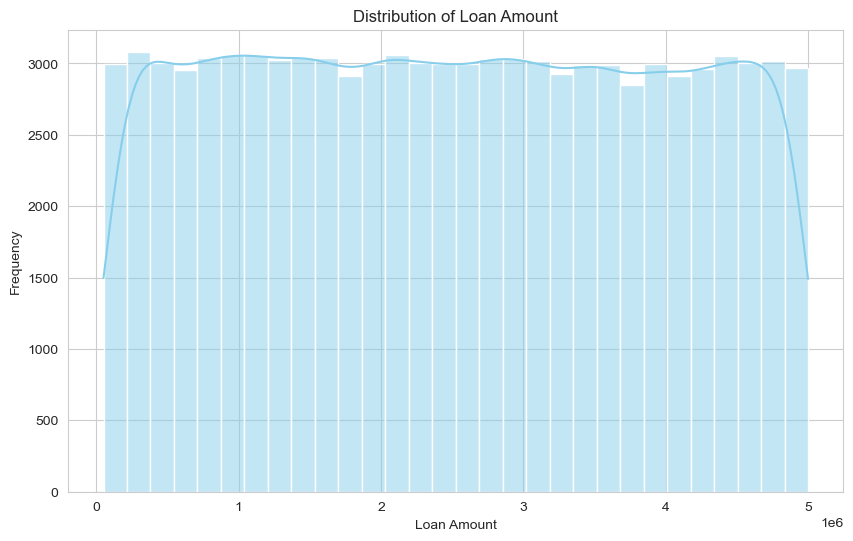

In [17]:
# Set up the aesthetic for the plots
sns.set_style("whitegrid")

# Distribution of Loan_Amount
plt.figure(figsize=(10, 6))
sns.histplot(df_loans['Loan_Amount'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

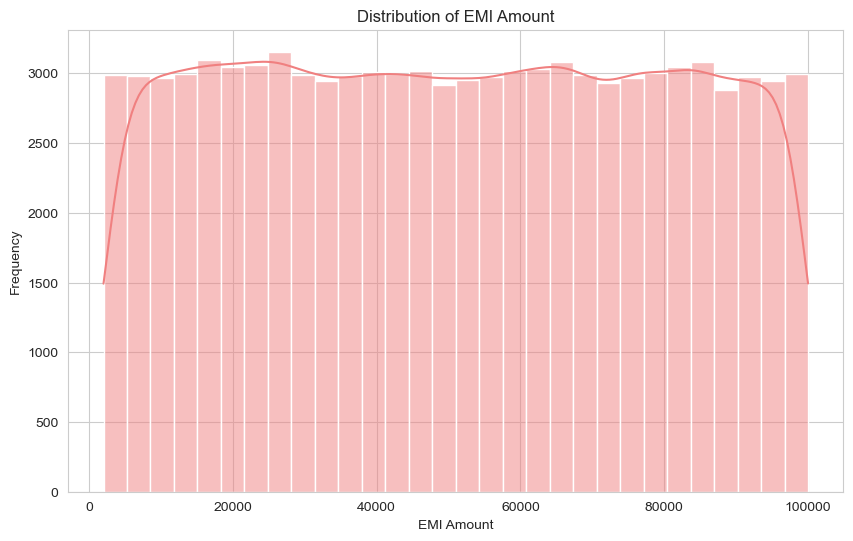

In [18]:
# Distribution of EMI_Amount
plt.figure(figsize=(10, 6))
sns.histplot(df_loans['EMI_Amount'], kde=True, bins=30, color='lightcoral')
plt.title('Distribution of EMI Amount')
plt.xlabel('EMI Amount')
plt.ylabel('Frequency')
plt.show()

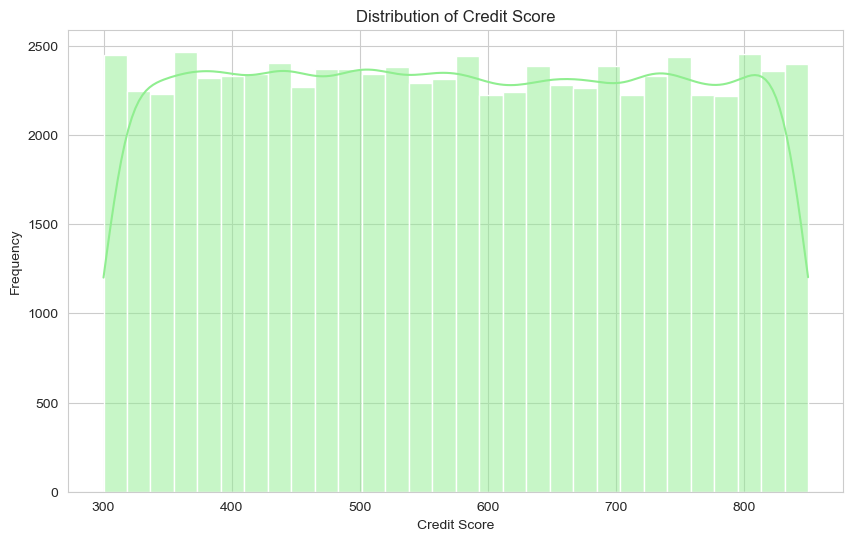

In [19]:
# Distribution of Credit_Score
plt.figure(figsize=(10, 6))
sns.histplot(df_customers['Credit_Score'], kde=True, bins=30, color='lightgreen')
plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()

In [20]:
# Merge df_loans with df_customers to get region information for loans
loans_regional = pd.merge(df_loans, df_customers[['Customer_ID', 'Region']], on='Customer_ID', how='left')

# Calculate total loan amount disbursed per region
regional_loan_disbursement = loans_regional.groupby('Region')['Loan_Amount'].sum().reset_index()
regional_loan_disbursement.rename(columns={'Loan_Amount': 'Total_Loan_Disbursed'}, inplace=True)

print('Regional Loan Disbursement:')
display(regional_loan_disbursement)

Regional Loan Disbursement:


,Region,Total_Loan_Disbursed
0,Central,37243437019
1,East,38437798746
2,North,37963952967
3,Northeast,37477362151
4,South,37740573537
5,West,37600155243


In [21]:
# Merge df_defaults with df_customers to get region information for defaults
defaults_regional = pd.merge(df_defaults, df_customers[['Customer_ID', 'Region']], on='Customer_ID', how='left')

# Calculate total defaults per region
regional_defaults = defaults_regional.groupby('Region').size().reset_index(name='Total_Defaults')

print('\nRegional Defaults:')
display(regional_defaults)


Regional Defaults:


,Region,Total_Defaults
0,Central,1158
1,East,1200
2,North,1169
3,Northeast,1155
4,South,1161
5,West,1171


In [22]:
# Combine loan disbursement and default data for regional analysis
regional_analysis = pd.merge(regional_loan_disbursement, regional_defaults, on='Region', how='outer').fillna(0)

# Calculate Default Rate per region (if applicable, avoiding division by zero)
regional_analysis['Default_Rate'] = (regional_analysis['Total_Defaults'] / regional_analysis['Total_Loan_Disbursed']) * 100
regional_analysis.loc[regional_analysis['Total_Loan_Disbursed'] == 0, 'Default_Rate'] = 0

print('\nCombined Regional Analysis:')
display(regional_analysis)

# Sort by Default_Rate for better visualization
regional_analysis_sorted = regional_analysis.sort_values(by='Default_Rate', ascending=False)


Combined Regional Analysis:


,Region,Total_Loan_Disbursed,Total_Defaults,Default_Rate
0,Central,37243437019,1158,0.000003
1,East,38437798746,1200,0.000003
2,North,37963952967,1169,0.000003
3,Northeast,37477362151,1155,0.000003
4,South,37740573537,1161,0.000003
5,West,37600155243,1171,0.000003


/var/folders/02/j6hqqdt54gn6z2k513lwgwsw0000gn/T/ipykernel_1720/1610685552.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Total_Loan_Disbursed', data=regional_analysis_sorted, palette='viridis')


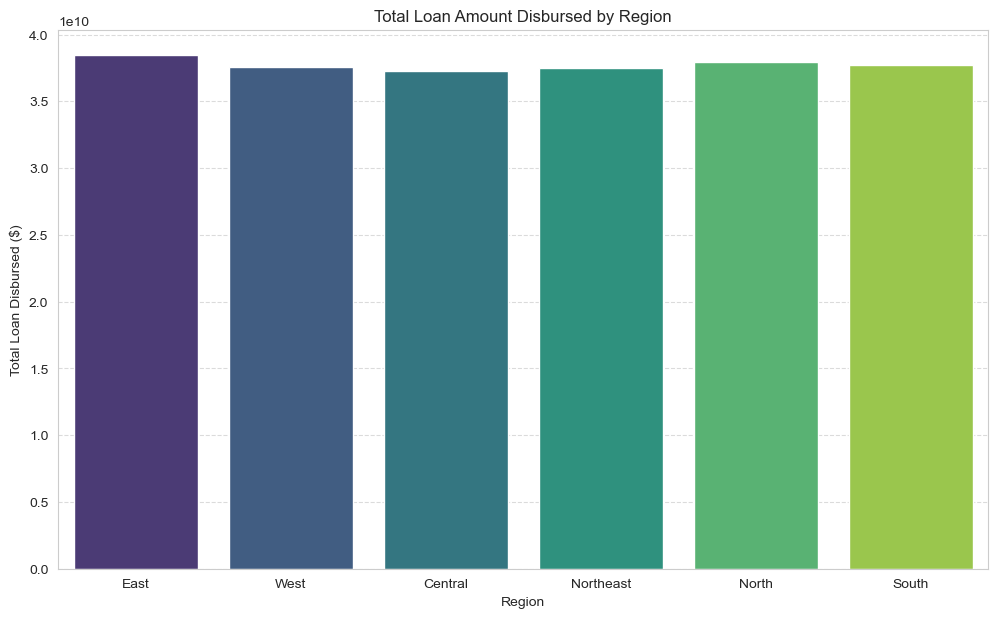

/var/folders/02/j6hqqdt54gn6z2k513lwgwsw0000gn/T/ipykernel_1720/1610685552.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Total_Defaults', data=regional_analysis_sorted, palette='magma')


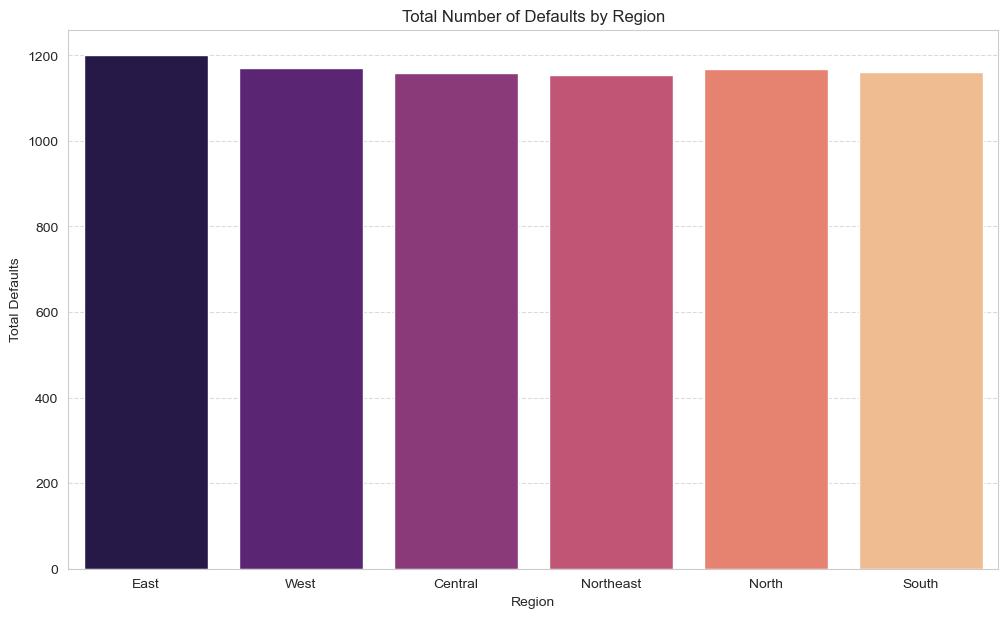

/var/folders/02/j6hqqdt54gn6z2k513lwgwsw0000gn/T/ipykernel_1720/1610685552.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Default_Rate', data=regional_analysis_sorted, palette='cividis')


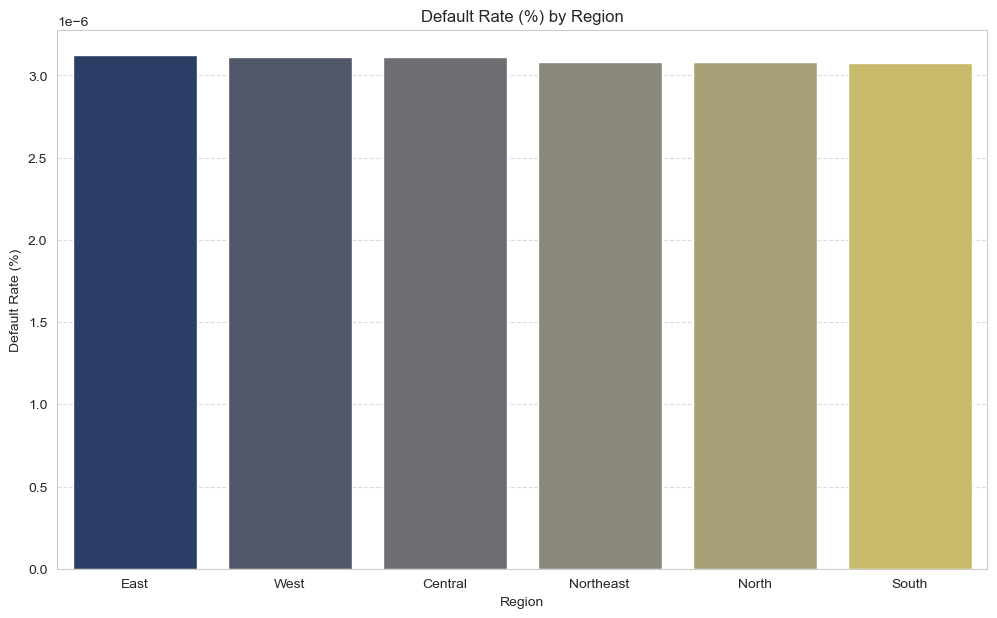

In [23]:
# Visualize Regional Loan Disbursement
plt.figure(figsize=(12, 7))
sns.barplot(x='Region', y='Total_Loan_Disbursed', data=regional_analysis_sorted, palette='viridis')
plt.title('Total Loan Amount Disbursed by Region')
plt.xlabel('Region')
plt.ylabel('Total Loan Disbursed ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualize Regional Defaults
plt.figure(figsize=(12, 7))
sns.barplot(x='Region', y='Total_Defaults', data=regional_analysis_sorted, palette='magma')
plt.title('Total Number of Defaults by Region')
plt.xlabel('Region')
plt.ylabel('Total Defaults')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualize Regional Default Rate
plt.figure(figsize=(12, 7))
sns.barplot(x='Region', y='Default_Rate', data=regional_analysis_sorted, palette='cividis')
plt.title('Default Rate (%) by Region')
plt.xlabel('Region')
plt.ylabel('Default Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [30]:
# Monthly Loan Approvals from df_application (for Approved Status)
approved_applications = df_application[df_application['Approval_Status'] == 'Approved'].copy()
approved_applications['Approval_Month_Year'] = approved_applications['Approval_Date'].dt.to_period('M')
monthly_approvals = approved_applications.groupby('Approval_Month_Year').size().reset_index(name='Total_Approvals')
monthly_approvals['Approval_Month_Year'] = monthly_approvals['Approval_Month_Year'].dt.to_timestamp()

# Monthly Loan Disbursements from df_loans
df_loans['Disbursal_Month_Year'] = df_loans['Disbursal_Date'].dt.to_period('M')
monthly_disbursements = df_loans.groupby('Disbursal_Month_Year')['Loan_Amount'].sum().reset_index(name='Total_Loan_Disbursed')
monthly_disbursements['Disbursal_Month_Year'] = monthly_disbursements['Disbursal_Month_Year'].dt.to_timestamp()

print('Monthly Loan Approvals:')
display(monthly_approvals.head())

print('\nMonthly Loan Disbursements:')
display(monthly_disbursements.head())

Monthly Loan Approvals:


,Approval_Month_Year,Total_Approvals
0,2020-01-01,1152
1,2020-02-01,1176
2,2020-03-01,1172
3,2020-04-01,1121
4,2020-05-01,1170



Monthly Loan Disbursements:


,Disbursal_Month_Year,Total_Loan_Disbursed
0,2019-12-01,491271344
1,2020-01-01,3908302834
2,2020-02-01,3621088694
3,2020-03-01,4031554268
4,2020-04-01,3817013578


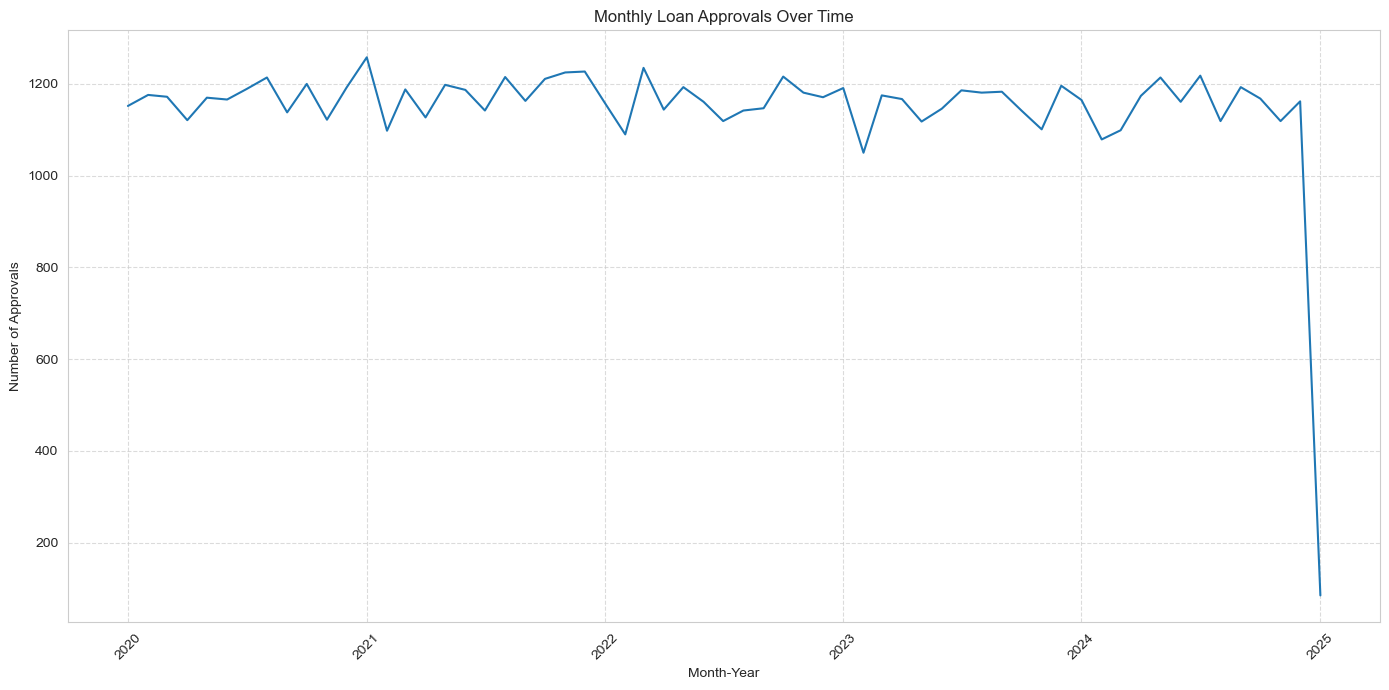

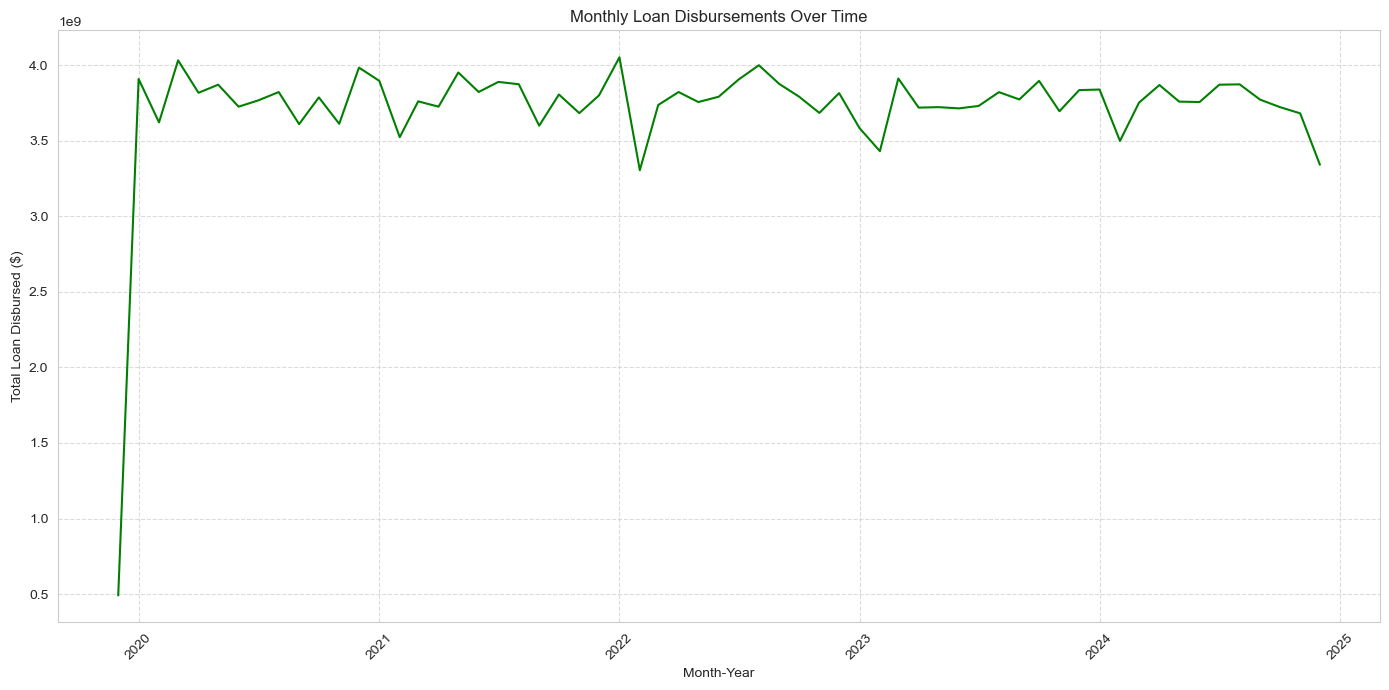

In [31]:
# Visualize Monthly Loan Approvals
plt.figure(figsize=(14, 7))
sns.lineplot(x='Approval_Month_Year', y='Total_Approvals', data=monthly_approvals)
plt.title('Monthly Loan Approvals Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Number of Approvals')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualize Monthly Loan Disbursements
plt.figure(figsize=(14, 7))
sns.lineplot(x='Disbursal_Month_Year', y='Total_Loan_Disbursed', data=monthly_disbursements, color='green')
plt.title('Monthly Loan Disbursements Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Total Loan Disbursed ($)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Default Risk Analysis
##      Correlation Between Loan Attributes and Defaults:
###           Calculate correlations between Loan_Amount, Interest_Rate, Credit_Score, and Default_Flag (a binary indicator for default).

##      Pairwise Correlation Analysis:
###           Create a heatmap to visualize the correlations between key variables, such as EMI_Amount, Overdue_Amount, and Default_Amount.

##      Correlation Between Branch Metrics and Defaults:
###           Analyze the relationship between branch performance metrics (e.g.,Delinquent_Loans, Loan_Disbursement_Amount) and default rates.

In [32]:
df_loans['Default_Flag'] = df_loans['Loan_ID'].isin(df_defaults['Loan_ID']).astype(int)

# Merge df_loans with df_customers to get 'Credit_Score'
correlation_df = pd.merge(df_loans, df_customers[['Customer_ID', 'Credit_Score']], on='Customer_ID', how='left')

# Select relevant columns for correlation
correlation_columns = ['Loan_Amount', 'Interest_Rate', 'Credit_Score', 'Default_Flag']
correlation_matrix = correlation_df[correlation_columns].corr()

print('Correlation Matrix:')
display(correlation_matrix)

Correlation Matrix:


,Loan_Amount,Interest_Rate,Credit_Score,Default_Flag
Loan_Amount,1.000000,-0.003201,0.000139,-0.003313
Interest_Rate,-0.003201,1.000000,0.002457,-0.003750
Credit_Score,0.000139,0.002457,1.000000,-0.001580
Default_Flag,-0.003313,-0.003750,-0.001580,1.000000


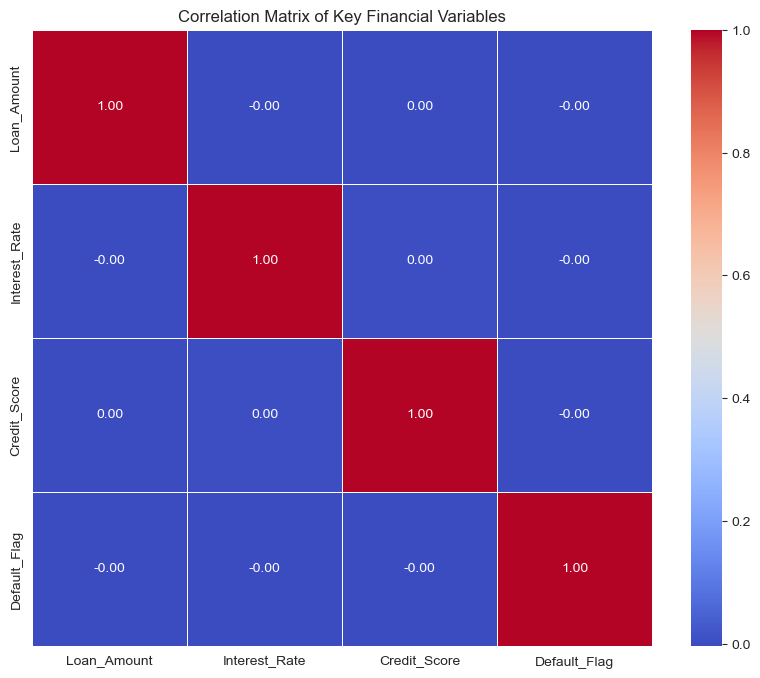

In [33]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Key Financial Variables')
plt.show()

In [34]:
# Merge df_defaults with correlation_df to include 'Default_Amount'
# Use a left merge to keep all loans and add default amount where applicable
correlation_financial_df = pd.merge(correlation_df, df_defaults[['Loan_ID', 'Default_Amount']], on='Loan_ID', how='left')

# Select relevant columns for correlation
financial_correlation_columns = ['EMI_Amount', 'Overdue_Amount', 'Default_Amount']
financial_correlation_matrix = correlation_financial_df[financial_correlation_columns].corr()

print('Correlation Matrix for Financial Specifics:')
display(financial_correlation_matrix)

Correlation Matrix for Financial Specifics:


,EMI_Amount,Overdue_Amount,Default_Amount
EMI_Amount,1.000000,0.000386,0.007650
Overdue_Amount,0.000386,1.000000,-0.010207
Default_Amount,0.007650,-0.010207,1.000000


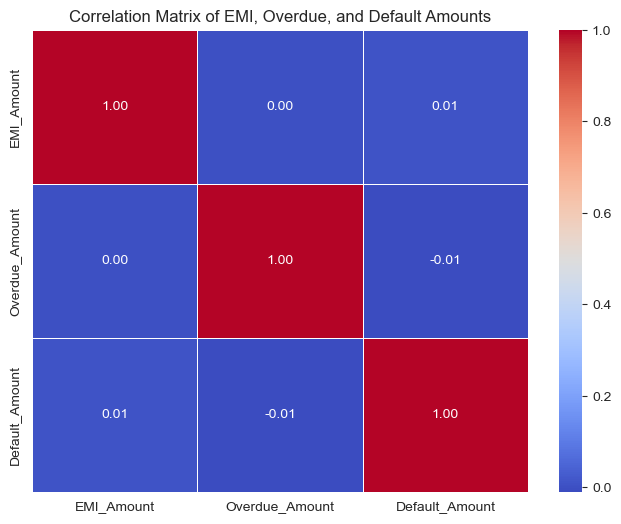

In [35]:
# Visualize the correlation matrix for financial specifics
plt.figure(figsize=(8, 6))
sns.heatmap(financial_correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of EMI, Overdue, and Default Amounts')
plt.show()

In [36]:
branch_performance = df_branches.copy()

# Add placeholder columns as the actual values cannot be computed due to missing data linkages.
branch_performance['Total_Loan_Disbursed_Actual'] = 0.0 # Placeholder: Cannot be computed due to missing data link
branch_performance['Total_Defaults'] = 0 # Placeholder: Cannot be computed due to missing data link

branch_performance['Default_Rate'] = (branch_performance['Total_Defaults'] / branch_performance['Total_Loan_Disbursed_Actual']) * 100
branch_performance.loc[branch_performance['Total_Loan_Disbursed_Actual'] == 0, 'Default_Rate'] = 0 # Handle division by zero

print('Branch Performance Metrics with Default Rate (placeholders due to missing data linkages):')
print('Note: Total_Loan_Disbursed_Actual and Total_Defaults could not be computed due to the absence of a "Branch_ID" column in df_customers or a direct aggregated column in df_branches.')
display(branch_performance.head())

Branch Performance Metrics with Default Rate (placeholders due to missing data linkages):
Note: Total_Loan_Disbursed_Actual and Total_Defaults could not be computed due to the absence of a "Branch_ID" column in df_customers or a direct aggregated column in df_branches.


,Branch_ID,Branch_Name,Region,Total_Customers,Total_Active_Loans,Delinquent_Loans,Loan_Disbursement_Amount,Avg_Processing_Time,Relationship_Manager_Count,Total_Loan_Disbursed_Actual,Total_Defaults,Default_Rate
0,B001,"Dhar, Kant and Madan",West,2891,279,21,341680882,6,29,0.0,0,0.0
1,B002,Shan Group,East,4459,1201,149,96549019,8,35,0.0,0,0.0
2,B003,Sachdev-Banerjee,Central,2504,122,168,445787808,12,48,0.0,0,0.0
3,B004,Kapadia-Brar,East,1542,1422,96,353934299,9,50,0.0,0,0.0
4,B005,"Mangal, Kaur and Borde",South,945,1613,87,311637902,11,10,0.0,0,0.0



Correlation Matrix for Branch Performance:


,Total_Customers,Total_Loan_Disbursed_Actual,Total_Defaults,Default_Rate
Total_Customers,1.0,NaN,NaN,NaN
Total_Loan_Disbursed_Actual,NaN,NaN,NaN,NaN
Total_Defaults,NaN,NaN,NaN,NaN
Default_Rate,NaN,NaN,NaN,NaN


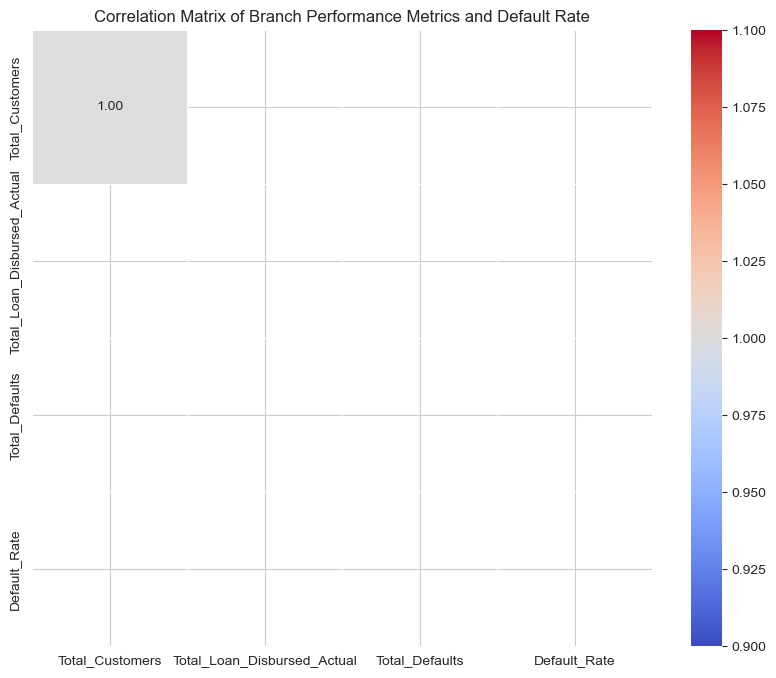

In [37]:
# Select relevant columns for correlation analysis from the updated branch_performance
correlation_columns_branch = ['Total_Customers', 'Total_Loan_Disbursed_Actual', 'Total_Defaults', 'Default_Rate']
branch_correlation_matrix = branch_performance[correlation_columns_branch].corr()

print('\nCorrelation Matrix for Branch Performance:')
display(branch_correlation_matrix)

# Visualize the correlation matrix for branch performance
plt.figure(figsize=(10, 8))
sns.heatmap(branch_correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Branch Performance Metrics and Default Rate')
plt.show()

# 4. Branch and Regional Performance
## Rank branches by:
### Loan disbursement volume.
### Processing time eﬃciency.
### Default rates and recovery rates.

## Compare branch performance across regions.

In [38]:
# Rank branches by Loan_Disbursement_Amount
branch_disbursement_rank = df_branches.sort_values(by='Loan_Disbursement_Amount', ascending=False).reset_index(drop=True)

print('Branches Ranked by Loan Disbursement Volume:')
display(branch_disbursement_rank[['Branch_Name', 'Region', 'Loan_Disbursement_Amount']].head(10))

Branches Ranked by Loan Disbursement Volume:


,Branch_Name,Region,Loan_Disbursement_Amount
0,Kara-Bahl,East,499562869
1,"Bhatti, Rau and Sem",North,482327541
2,Kaul Inc,West,465469874
3,Chawla-Subramanian,Central,464419943
4,"Malhotra, Boase and Malhotra",Central,449109596
5,Grover Group,East,447832443
6,Sachdev-Banerjee,Central,445787808
7,Sani-Kale,North,442594434
8,Arya Ltd,West,435407779
9,Yogi Ltd,North,420746720


In [39]:
# Rank branches by Avg_Processing_Time (ascending for efficiency)
branch_processing_efficiency = df_branches.sort_values(by='Avg_Processing_Time', ascending=True).reset_index(drop=True)

print('Branches Ranked by Processing Time Efficiency:')
display(branch_processing_efficiency[['Branch_Name', 'Region', 'Avg_Processing_Time']].head(10))

Branches Ranked by Processing Time Efficiency:


,Branch_Name,Region,Avg_Processing_Time
0,Sani-Kale,North,1
1,Chawla-Tandon,East,2
2,Kar-Jaggi,West,2
3,"Sandhu, Magar and Sachdeva",Northeast,2
4,Solanki-Shah,South,3
5,Kapadia-Ramakrishnan,West,3
6,Kaul Inc,West,3
7,Chawla-Subramanian,Central,4
8,"Saini, Iyer and Sani",South,5
9,"Wable, Butala and Kakar",South,5


In [40]:
# Rank branches by Default_Rate (ascending for better performance)
branch_default_rank = branch_performance.sort_values(by='Default_Rate', ascending=True).reset_index(drop=True)

print('Branches Ranked by Default Rate (Lowest to Highest):')
display(branch_default_rank[['Branch_Name', 'Region', 'Default_Rate']].head(10))

Branches Ranked by Default Rate (Lowest to Highest):


,Branch_Name,Region,Default_Rate
0,"Dhar, Kant and Madan",West,0.0
1,"Borah, Comar and Bhalla",Central,0.0
2,"Uppal, Sankaran and Thaker",Central,0.0
3,Kakar-Dutta,East,0.0
4,Sem Inc,South,0.0
5,Mahajan-Zachariah,Northeast,0.0
6,"Saini, Iyer and Sani",South,0.0
7,"Raja, Ratta and Sathe",Central,0.0
8,"Malhotra, Boase and Malhotra",Central,0.0
9,Kara-Bahl,East,0.0


In [42]:
branch_performance['Total_Loan_Disbursed_Actual'] = branch_performance['Loan_Disbursement_Amount']
branch_performance['Total_Defaults'] = branch_performance['Delinquent_Loans']

# Calculate Default Rate
# Handle division by zero for branches with no disbursed loans
branch_performance['Default_Rate'] = (branch_performance['Total_Defaults'] / branch_performance['Total_Loan_Disbursed_Actual']) * 100
branch_performance.loc[branch_performance['Total_Loan_Disbursed_Actual'] == 0, 'Default_Rate'] = 0 # Handle division by zero

print('Branch Performance Metrics (calculated using aggregated data from df_branches):')
display(branch_performance.head())

Branch Performance Metrics (calculated using aggregated data from df_branches):


,Branch_ID,Branch_Name,Region,Total_Customers,Total_Active_Loans,Delinquent_Loans,Loan_Disbursement_Amount,Avg_Processing_Time,Relationship_Manager_Count,Total_Loan_Disbursed_Actual,Total_Defaults,Default_Rate
0,B001,"Dhar, Kant and Madan",West,2891,279,21,341680882,6,29,341680882,21,0.000006
1,B002,Shan Group,East,4459,1201,149,96549019,8,35,96549019,149,0.000154
2,B003,Sachdev-Banerjee,Central,2504,122,168,445787808,12,48,445787808,168,0.000038
3,B004,Kapadia-Brar,East,1542,1422,96,353934299,9,50,353934299,96,0.000027
4,B005,"Mangal, Kaur and Borde",South,945,1613,87,311637902,11,10,311637902,87,0.000028


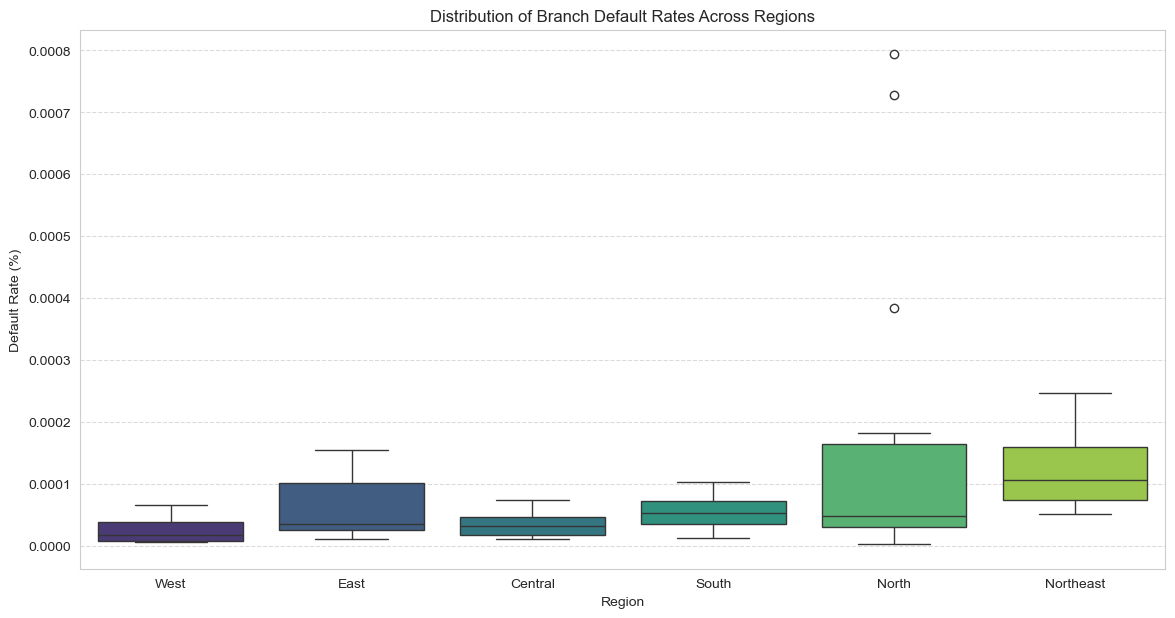

In [43]:
# Visualize the distribution of Default_Rate per Region for individual branches
plt.figure(figsize=(14, 7))
sns.boxplot(x='Region', y='Default_Rate', data=branch_performance, palette='viridis', hue='Region', legend=False)
plt.title('Distribution of Branch Default Rates Across Regions')
plt.xlabel('Region')
plt.ylabel('Default Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 5. Customer Segmentation
## Segment customers by income, credit score, and loan status.
## Identify high-risk and high-value customer groups.
## Analyze repayment behavior across segments.

In [44]:
customer_loan_segment_df = pd.merge(df_customers, df_loans, on='Customer_ID', how='inner')

# Display the head of the merged DataFrame to verify
print('Merged Customer and Loan Data:')
display(customer_loan_segment_df.head())

Merged Customer and Loan Data:


,Customer_ID,Full_Name,Contact_Number,Email,Address,Age,Gender,Marital_Status,Employment_Status,Annual_Income,...,Loan_Term,Disbursal_Date,Repayment_Start_Date,Repayment_End_Date,Loan_Status,Overdue_Amount,EMI_Amount,Collateral_Details,Disbursal_Month_Year,Default_Flag
0,C000003,Rhea Bhargava,910320534937,bahlelakshi@mall.info,"67/386\nComar Nagar, Chapra 137669",62,Other,Single,Self-Employed,1118591,...,60,2024-06-30,2024-07-30,2029-06-30,Closed,0,28882,NaN,2024-06,0
1,C000003,Rhea Bhargava,910320534937,bahlelakshi@mall.info,"67/386\nComar Nagar, Chapra 137669",62,Other,Single,Self-Employed,1118591,...,24,2021-01-10,2021-02-10,2023-01-10,Overdue,44073,58437,NaN,2021-01,0
2,C000004,Indrans Walia,6566372162,akadakia@yahoo.com,88\nDhillon Ganj\nJamshedpur-816278,59,Female,Single,Salaried,524075,...,12,2021-06-01,2021-07-01,2022-06-01,Closed,0,13389,Property,2021-06,0
3,C000004,Indrans Walia,6566372162,akadakia@yahoo.com,88\nDhillon Ganj\nJamshedpur-816278,59,Female,Single,Salaried,524075,...,24,2021-08-31,2021-09-30,2023-08-31,Overdue,0,37450,NaN,2021-08,0
4,C000004,Indrans Walia,6566372162,akadakia@yahoo.com,88\nDhillon Ganj\nJamshedpur-816278,59,Female,Single,Salaried,524075,...,36,2023-08-23,2023-09-23,2026-08-23,Active,0,65252,Property,2023-08,0


In [45]:
# Create Income bins
income_bins = [0, 50000, 100000, 200000, np.inf]
income_labels = ['Low', 'Medium', 'High', 'Very High']
customer_loan_segment_df['Income_Group'] = pd.cut(customer_loan_segment_df['Annual_Income'], bins=income_bins, labels=income_labels, right=False)

# Create Credit Score bins
credit_bins = [0, 580, 670, 740, 850]
credit_labels = ['Poor', 'Fair', 'Good', 'Excellent']
customer_loan_segment_df['Credit_Score_Group'] = pd.cut(customer_loan_segment_df['Credit_Score'], bins=credit_bins, labels=credit_labels, right=False)

print('\nDataFrame with Income and Credit Score Groups:')
display(customer_loan_segment_df[['Customer_ID', 'Annual_Income', 'Income_Group', 'Credit_Score', 'Credit_Score_Group', 'Loan_Status']].head())


DataFrame with Income and Credit Score Groups:


,Customer_ID,Annual_Income,Income_Group,Credit_Score,Credit_Score_Group,Loan_Status
0,C000003,1118591,Very High,736,Good,Closed
1,C000003,1118591,Very High,736,Good,Overdue
2,C000004,524075,Very High,353,Poor,Closed
3,C000004,524075,Very High,353,Poor,Overdue
4,C000004,524075,Very High,353,Poor,Active


In [46]:
# Segment customers and analyze Loan_Status distribution
segmentation_results = customer_loan_segment_df.groupby(['Income_Group', 'Credit_Score_Group', 'Loan_Status']).size().unstack(fill_value=0)

print('\nCustomer Segmentation Results (Loan Status Distribution):')
display(segmentation_results)

# You can also normalize these results to see percentages within each segment
segmentation_percentage = segmentation_results.groupby(level=[0,1]).apply(lambda x: 100 * x / x.sum())
print('\nCustomer Segmentation Results (Loan Status Percentage):')
display(segmentation_percentage)


Customer Segmentation Results (Loan Status Distribution):


/var/folders/02/j6hqqdt54gn6z2k513lwgwsw0000gn/T/ipykernel_1720/2166015999.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segmentation_results = customer_loan_segment_df.groupby(['Income_Group', 'Credit_Score_Group', 'Loan_Status']).size().unstack(fill_value=0)


Loan_Status                      Active  Closed  Overdue
Income_Group Credit_Score_Group                         
Low          Poor                     0       0        0
             Fair                     0       0        0
             Good                     0       0        0
             Excellent                0       0        0
Medium       Poor                     0       0        0
             Fair                     0       0        0
             Good                     0       0        0
             Excellent                0       0        0
High         Poor                     0       0        0
             Fair                     0       0        0
             Good                     0       0        0
             Excellent                0       0        0
Very High    Poor                 15341   15406    15350
             Fair                  4842    4850     4811
             Good                  3774    3852     3796
             Excellent             6050    5923     5861


Customer Segmentation Results (Loan Status Percentage):


/var/folders/02/j6hqqdt54gn6z2k513lwgwsw0000gn/T/ipykernel_1720/2166015999.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segmentation_percentage = segmentation_results.groupby(level=[0,1]).apply(lambda x: 100 * x / x.sum())


Loan_Status                                                      Active  \
Income_Group Credit_Score_Group Income_Group Credit_Score_Group           
Low          Poor               Low          Poor                   NaN   
             Fair               Low          Fair                   NaN   
             Good               Low          Good                   NaN   
             Excellent          Low          Excellent              NaN   
Medium       Poor               Medium       Poor                   NaN   
             Fair               Medium       Fair                   NaN   
             Good               Medium       Good                   NaN   
             Excellent          Medium       Excellent              NaN   
High         Poor               High         Poor                   NaN   
             Fair               High         Fair                   NaN   
             Good               High         Good                   NaN   
             Excellent          High         Excellent              NaN   
Very High    Poor               Very High    Poor                 100.0   
             Fair               Very High    Fair                 100.0   
             Good               Very High    Good                 100.0   
             Excellent          Very High    Excellent            100.0   

Loan_Status                                                      Closed  \
Income_Group Credit_Score_Group Income_Group Credit_Score_Group           
Low          Poor               Low          Poor                   NaN   
             Fair               Low          Fair                   NaN   
             Good               Low          Good                   NaN   
             Excellent          Low          Excellent              NaN   
Medium       Poor               Medium       Poor                   NaN   
             Fair               Medium       Fair                   NaN   
             Good               Medium       Good                   NaN   
             Excellent          Medium       Excellent              NaN   
High         Poor               High         Poor                   NaN   
             Fair               High         Fair                   NaN   
             Good               High         Good                   NaN   
             Excellent          High         Excellent              NaN   
Very High    Poor               Very High    Poor                 100.0   
             Fair               Very High    Fair                 100.0   
             Good               Very High    Good                 100.0   
             Excellent          Very High    Excellent            100.0   

Loan_Status                                                      Overdue  
Income_Group Credit_Score_Group Income_Group Credit_Score_Group           
Low          Poor               Low          Poor                    NaN  
             Fair               Low          Fair                    NaN  
             Good               Low          Good                    NaN  
             Excellent          Low          Excellent               NaN  
Medium       Poor               Medium       Poor                    NaN  
             Fair               Medium       Fair                    NaN  
             Good               Medium       Good                    NaN  
             Excellent          Medium       Excellent               NaN  
High         Poor               High         Poor                    NaN  
             Fair               High         Fair                    NaN  
             Good               High         Good                    NaN  
             Excellent          High         Excellent               NaN  
Very High    Poor               Very High    Poor                  100.0  
             Fair               Very High    Fair                  100.0  
             Good               Very High    Good                  100.0  
             Excellent 

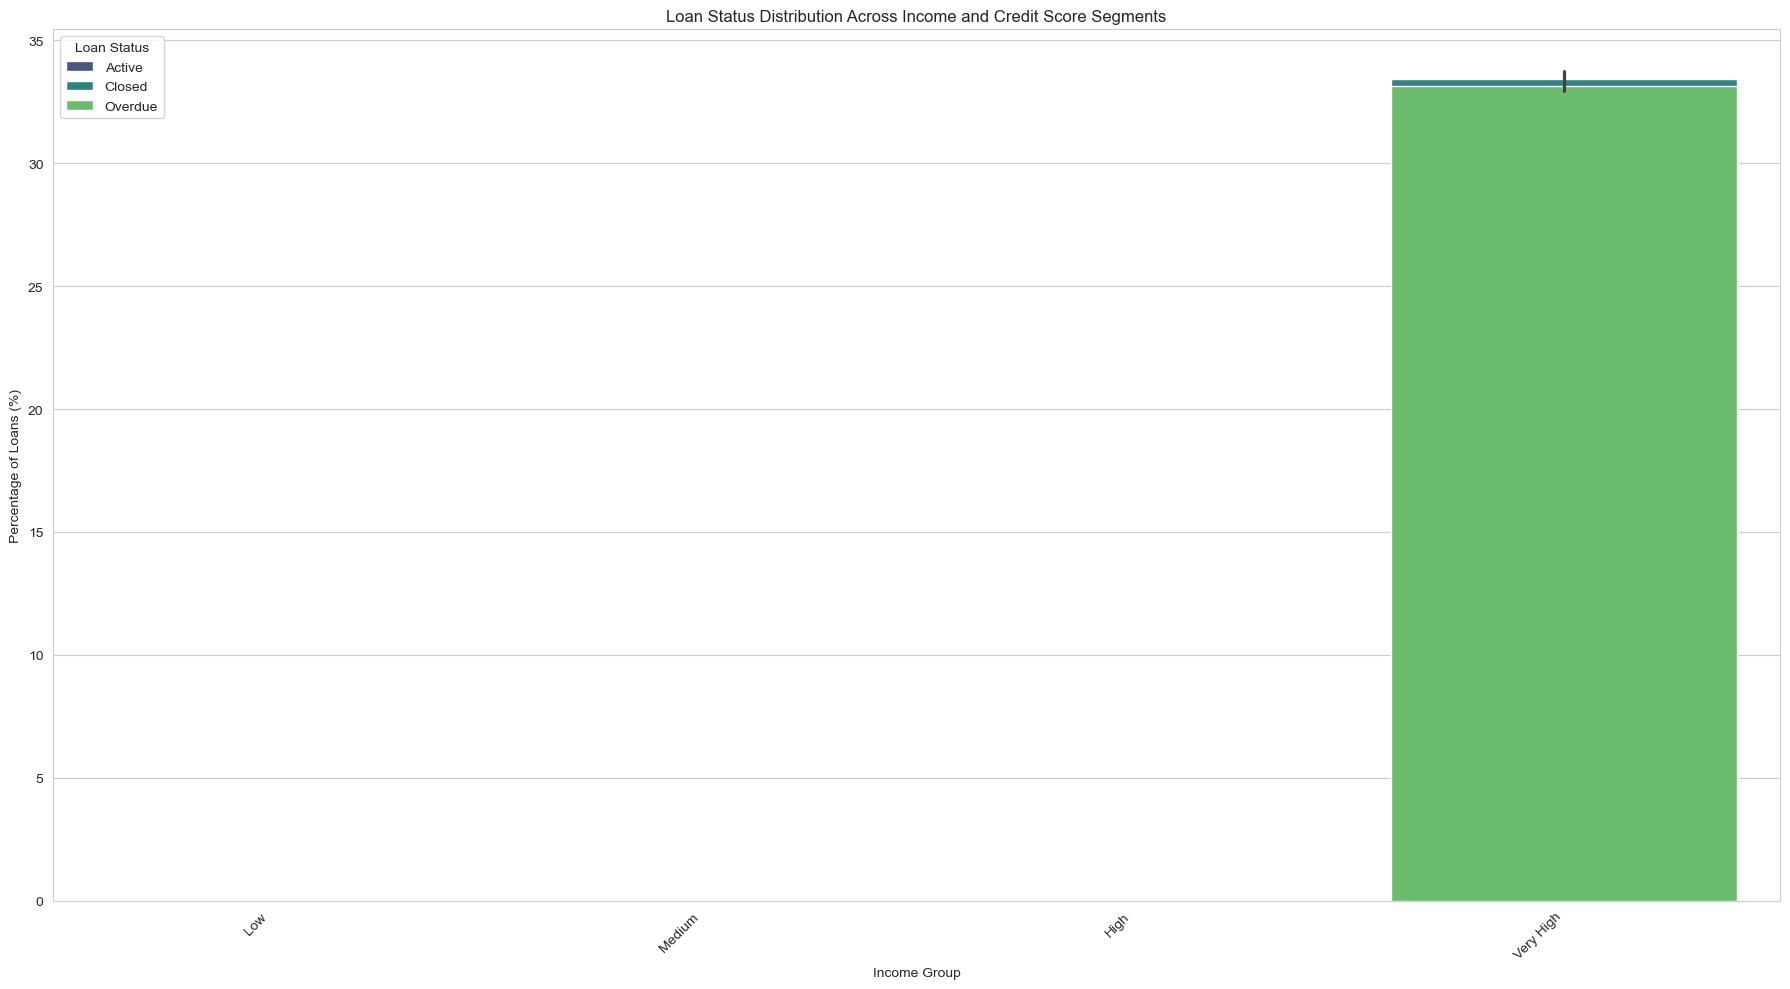

In [47]:
segmentation_percentage_for_plot = segmentation_results.apply(lambda x: 100 * x / x.sum(), axis=1)

# Reset the index to turn Income_Group and Credit_Score_Group into columns
segmentation_plot_df = segmentation_percentage_for_plot.reset_index()

# Melt the DataFrame to transform the 'Loan_Status' columns ('Active', 'Closed', 'Overdue') into rows
segmentation_plot_df = segmentation_plot_df.melt(
    id_vars=['Income_Group', 'Credit_Score_Group'],
    var_name='Loan_Status',
    value_name='Percentage'
)

# Create a figure and a set of subplots
plt.figure(figsize=(18, 10))
sns.set_style("whitegrid")

# Create a stacked bar chart
sns.barplot(x='Income_Group', y='Percentage', hue='Loan_Status', data=segmentation_plot_df,
            palette='viridis', dodge=False)

plt.title('Loan Status Distribution Across Income and Credit Score Segments')
plt.xlabel('Income Group')
plt.ylabel('Percentage of Loans (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Loan Status')
plt.tight_layout()
plt.show()

### 6. Advanced Statistical Analysis

In [48]:
# Merge df_loans with df_customers to include Credit_Score
combined_correlation_df = pd.merge(df_loans, df_customers[['Customer_ID', 'Credit_Score']], on='Customer_ID', how='left')

# Select relevant columns for the combined correlation analysis
combined_correlation_columns = ['Credit_Score', 'Loan_Amount', 'Interest_Rate', 'Overdue_Amount', 'Default_Flag']
combined_correlation_matrix = combined_correlation_df[combined_correlation_columns].corr()

print('Combined Correlation Matrix:')
display(combined_correlation_matrix)


Combined Correlation Matrix:


,Credit_Score,Loan_Amount,Interest_Rate,Overdue_Amount,Default_Flag
Credit_Score,1.000000,0.000139,0.002457,0.001570,-0.001580
Loan_Amount,0.000139,1.000000,-0.003201,0.008400,-0.003313
Interest_Rate,0.002457,-0.003201,1.000000,-0.002199,-0.003750
Overdue_Amount,0.001570,0.008400,-0.002199,1.000000,-0.000687
Default_Flag,-0.001580,-0.003313,-0.003750,-0.000687,1.000000


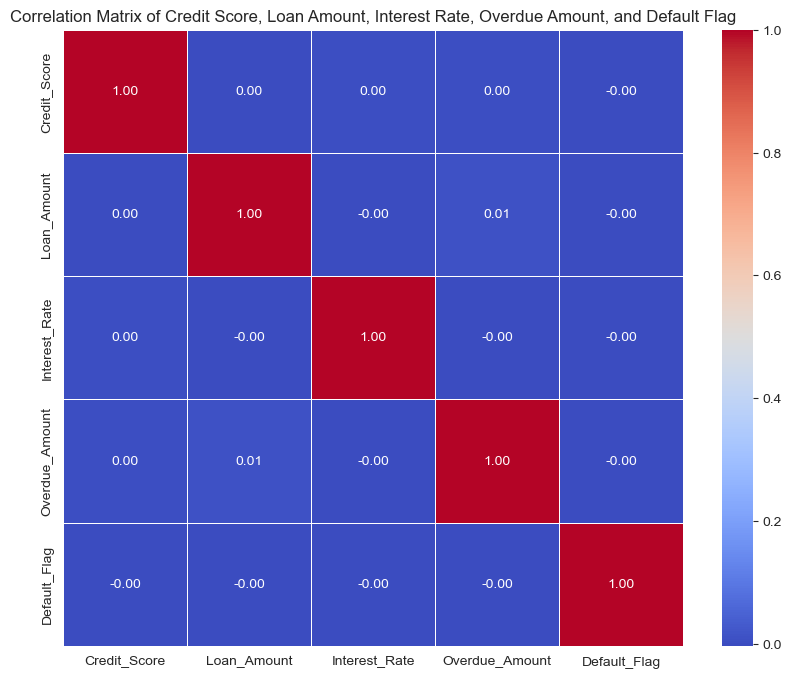

In [49]:
plt.figure(figsize=(10, 8))
sns.heatmap(combined_correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Credit Score, Loan Amount, Interest Rate, Overdue Amount, and Default Flag')
plt.show()

In [50]:
# Calculate Recovery_Rate in df_defaults
# Handle cases where Default_Amount might be 0 to avoid division by zero errors
df_defaults['Recovery_Rate'] = np.where(
    df_defaults['Default_Amount'] > 0,
    df_defaults['Recovery_Amount'] / df_defaults['Default_Amount'],
    0 # Set Recovery_Rate to 0 if Default_Amount is 0
)

# Merge df_loans with df_defaults to get EMI_Amount, Recovery_Rate, and Default_Amount
# Use a left merge from df_loans to keep all loans, and bring in default info where available
correlation_recovery_df = pd.merge(df_loans[['Loan_ID', 'EMI_Amount']],
                                 df_defaults[['Loan_ID', 'Default_Amount', 'Recovery_Rate']],
                                 on='Loan_ID', how='left')

# Fill NaN values for loans that did not default (as they won't have Default_Amount or Recovery_Rate)
correlation_recovery_df['Default_Amount'] = correlation_recovery_df['Default_Amount'].fillna(0)
correlation_recovery_df['Recovery_Rate'] = correlation_recovery_df['Recovery_Rate'].fillna(0)

# Select relevant columns for correlation
recovery_correlation_columns = ['EMI_Amount', 'Default_Amount', 'Recovery_Rate']
recovery_correlation_matrix = correlation_recovery_df[recovery_correlation_columns].corr()

print('Correlation Matrix for EMI, Default Amount, and Recovery Rate:')
display(recovery_correlation_matrix)

Correlation Matrix for EMI, Default Amount, and Recovery Rate:


,EMI_Amount,Default_Amount,Recovery_Rate
EMI_Amount,1.000000,0.003073,-0.001442
Default_Amount,0.003073,1.000000,0.204984
Recovery_Rate,-0.001442,0.204984,1.000000


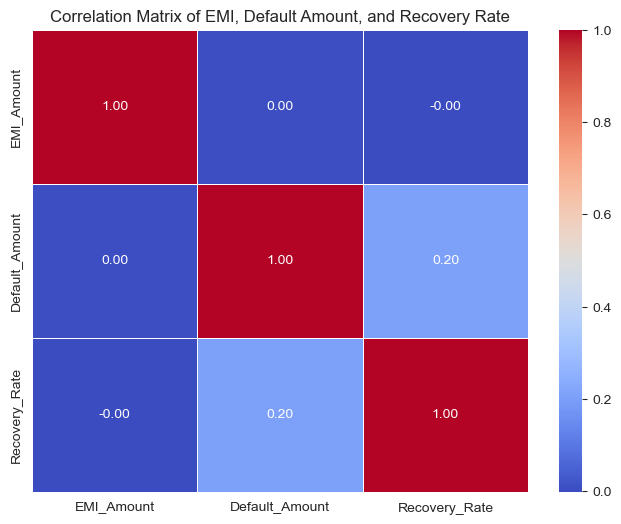

In [51]:
plt.figure(figsize=(8, 6))
sns.heatmap(recovery_correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of EMI, Default Amount, and Recovery Rate')
plt.show()

In [52]:
branch_metrics_df = df_branches[['Delinquent_Loans', 'Loan_Disbursement_Amount', 'Avg_Processing_Time', 'Total_Customers']]

# Calculate the correlation matrix
branch_efficiency_correlation_matrix = branch_metrics_df.corr()

print('Correlation Matrix for Branch Performance and Efficiency Metrics:')
display(branch_efficiency_correlation_matrix)

Correlation Matrix for Branch Performance and Efficiency Metrics:


,Delinquent_Loans,Loan_Disbursement_Amount,Avg_Processing_Time,Total_Customers
Delinquent_Loans,1.000000,0.023648,-0.022108,-0.017379
Loan_Disbursement_Amount,0.023648,1.000000,-0.060313,0.006648
Avg_Processing_Time,-0.022108,-0.060313,1.000000,-0.134411
Total_Customers,-0.017379,0.006648,-0.134411,1.000000


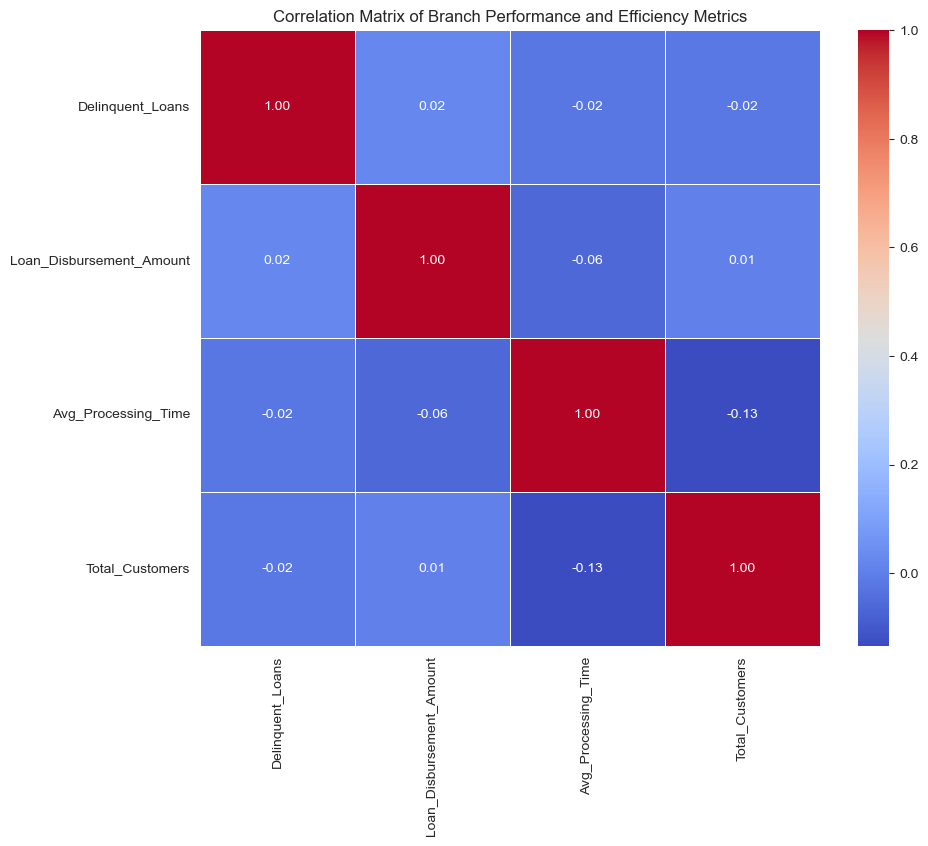

In [53]:
# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(branch_efficiency_correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Branch Performance and Efficiency Metrics')
plt.show()

# 7. Transaction and Recovery Analysis

In [58]:
penalty_payments = df_transactions[df_transactions['Payment_Type'] == 'Penalty'].copy()

# Extract month and year for aggregation
penalty_payments['Transaction_Month_Year'] = penalty_payments['Transaction_Date'].dt.to_period('M')

# Aggregate penalty amounts by month
monthly_penalty_payments = penalty_payments.groupby('Transaction_Month_Year')['Amount'].sum().reset_index()
monthly_penalty_payments['Transaction_Month_Year'] = monthly_penalty_payments['Transaction_Month_Year'].dt.to_timestamp()

print('Monthly Penalty Payments:')
display(monthly_penalty_payments.head())

Monthly Penalty Payments:


,Transaction_Month_Year,Amount
0,2019-12-01,13303625
1,2020-01-01,106916133
2,2020-02-01,105960952
3,2020-03-01,106585687
4,2020-04-01,100063569


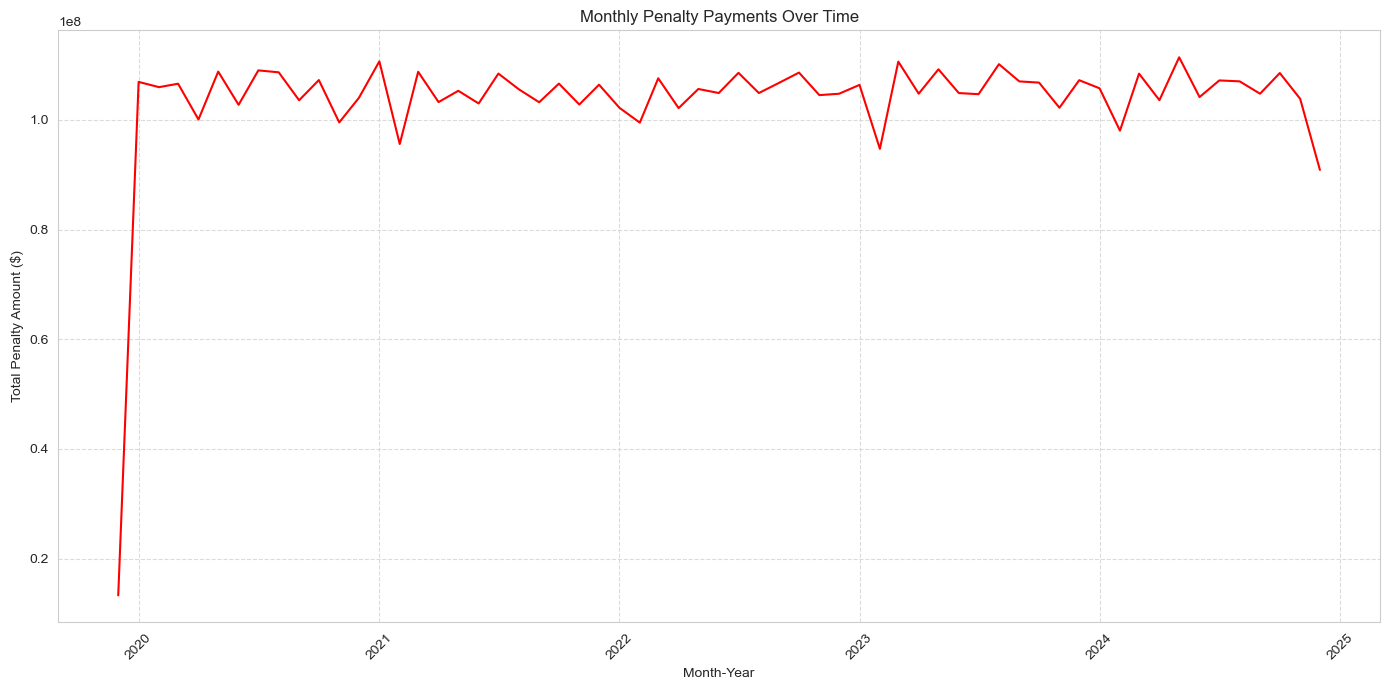

In [59]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='Transaction_Month_Year', y='Amount', data=monthly_penalty_payments, color='red')
plt.title('Monthly Penalty Payments Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Total Penalty Amount ($)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [60]:
# Ensure 'Disbursal_Date' is datetime and create month-year for aggregation
# (Assuming overdue amount is recorded around disbursal or repayment start, using disbursal for a general trend)
df_loans['Disbursal_Month_Year'] = df_loans['Disbursal_Date'].dt.to_period('M')

# Aggregate total overdue amount by month of disbursal
monthly_overdue_amounts = df_loans.groupby('Disbursal_Month_Year')['Overdue_Amount'].sum().reset_index()
monthly_overdue_amounts['Disbursal_Month_Year'] = monthly_overdue_amounts['Disbursal_Month_Year'].dt.to_timestamp()

print('Monthly Total Overdue Amounts (by Disbursal Month):')
display(monthly_overdue_amounts.head())

Monthly Total Overdue Amounts (by Disbursal Month):


,Disbursal_Month_Year,Overdue_Amount
0,2019-12-01,2518345
1,2020-01-01,20487375
2,2020-02-01,19003752
3,2020-03-01,18771857
4,2020-04-01,20412621


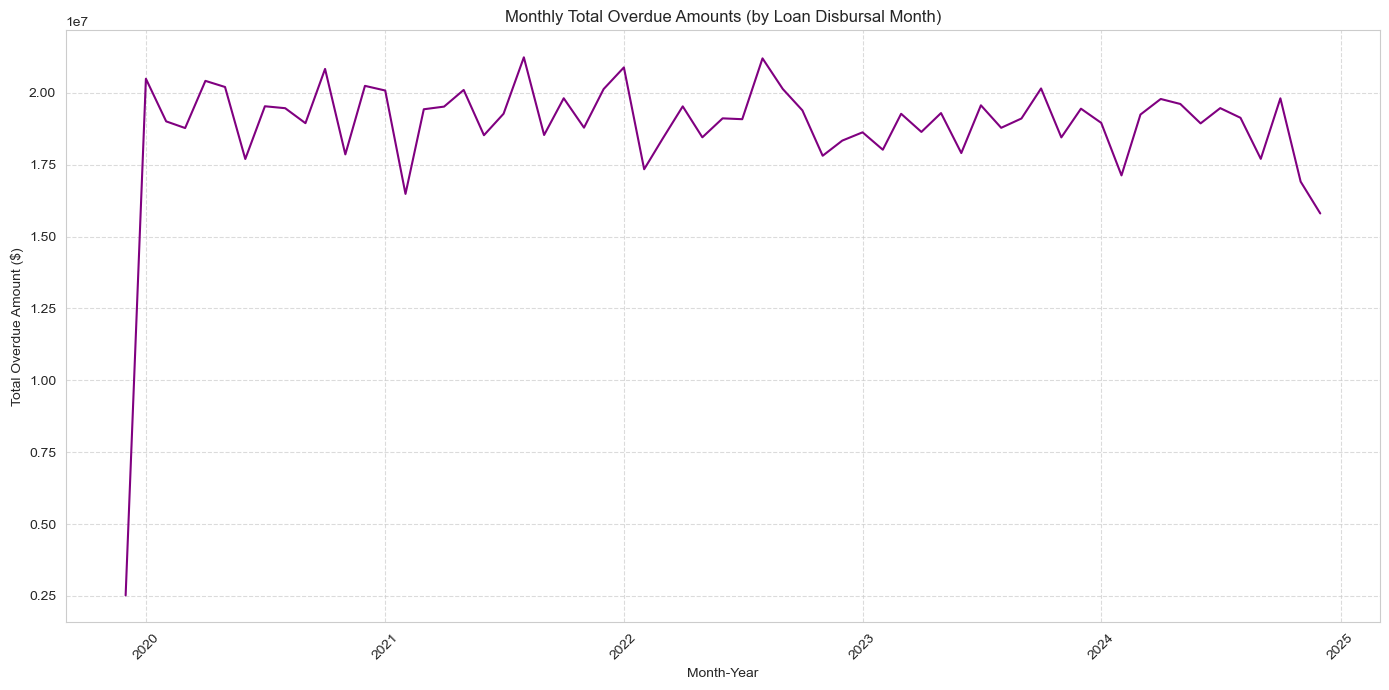

In [61]:
# Visualize Monthly Overdue Amounts
plt.figure(figsize=(14, 7))
sns.lineplot(x='Disbursal_Month_Year', y='Overdue_Amount', data=monthly_overdue_amounts, color='purple')
plt.title('Monthly Total Overdue Amounts (by Loan Disbursal Month)')
plt.xlabel('Month-Year')
plt.ylabel('Total Overdue Amount ($)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [63]:
recovery_by_reason_action = df_defaults.groupby(['Default_Reason', 'Legal_Action'])['Recovery_Rate'].mean().reset_index()

print('Average Recovery Rate by Default Reason and Legal Action:')
display(recovery_by_reason_action)

Average Recovery Rate by Default Reason and Legal Action:


,Default_Reason,Legal_Action,Recovery_Rate
0,Business Failure,No,0.404936
1,Business Failure,Yes,0.402335
2,Job Loss,No,0.393805
3,Job Loss,Yes,0.418474
4,Medical Emergency,No,0.420908
5,Medical Emergency,Yes,0.414707
6,Other,No,0.386740
7,Other,Yes,0.394871


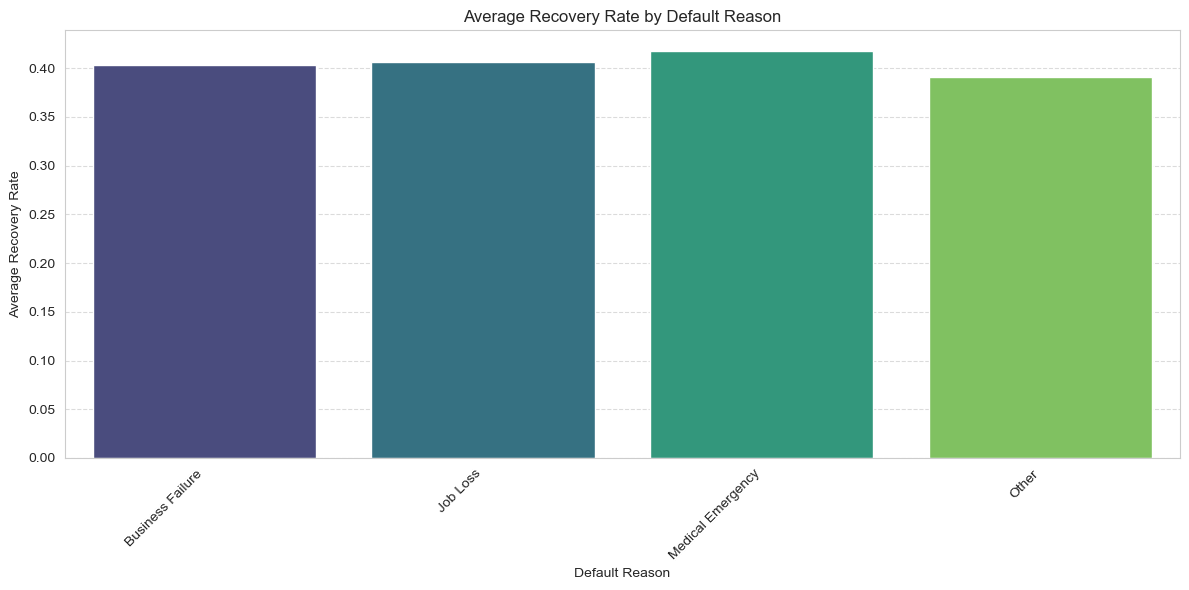

In [65]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Default_Reason', y='Recovery_Rate', hue='Default_Reason', data=recovery_by_reason_action.groupby('Default_Reason')['Recovery_Rate'].mean().reset_index(), palette='viridis', legend=False)
plt.title('Average Recovery Rate by Default Reason')
plt.xlabel('Default Reason')
plt.ylabel('Average Recovery Rate')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

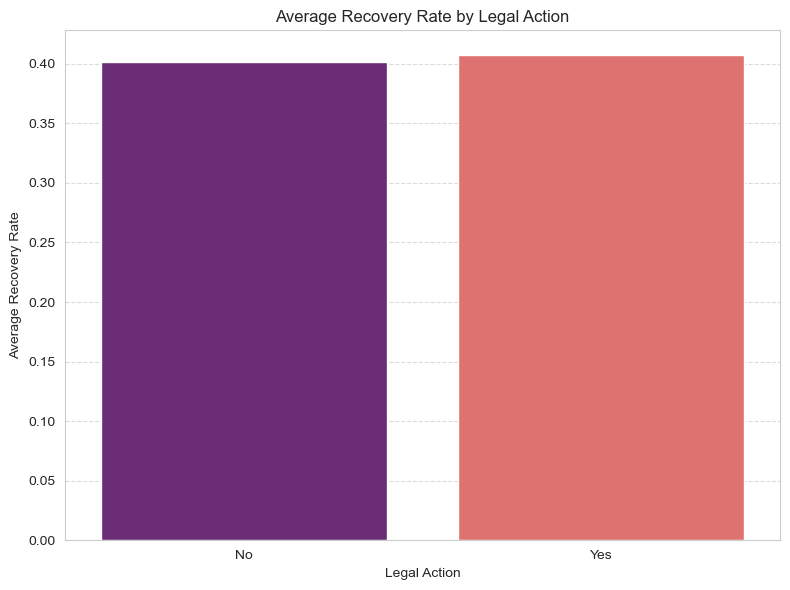

In [66]:
# Visualize Recovery_Rate by Legal_Action
plt.figure(figsize=(8, 6))
sns.barplot(x='Legal_Action', y='Recovery_Rate', hue='Legal_Action', data=recovery_by_reason_action.groupby('Legal_Action')['Recovery_Rate'].mean().reset_index(), palette='magma', legend=False)
plt.title('Average Recovery Rate by Legal Action')
plt.xlabel('Legal Action')
plt.ylabel('Average Recovery Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

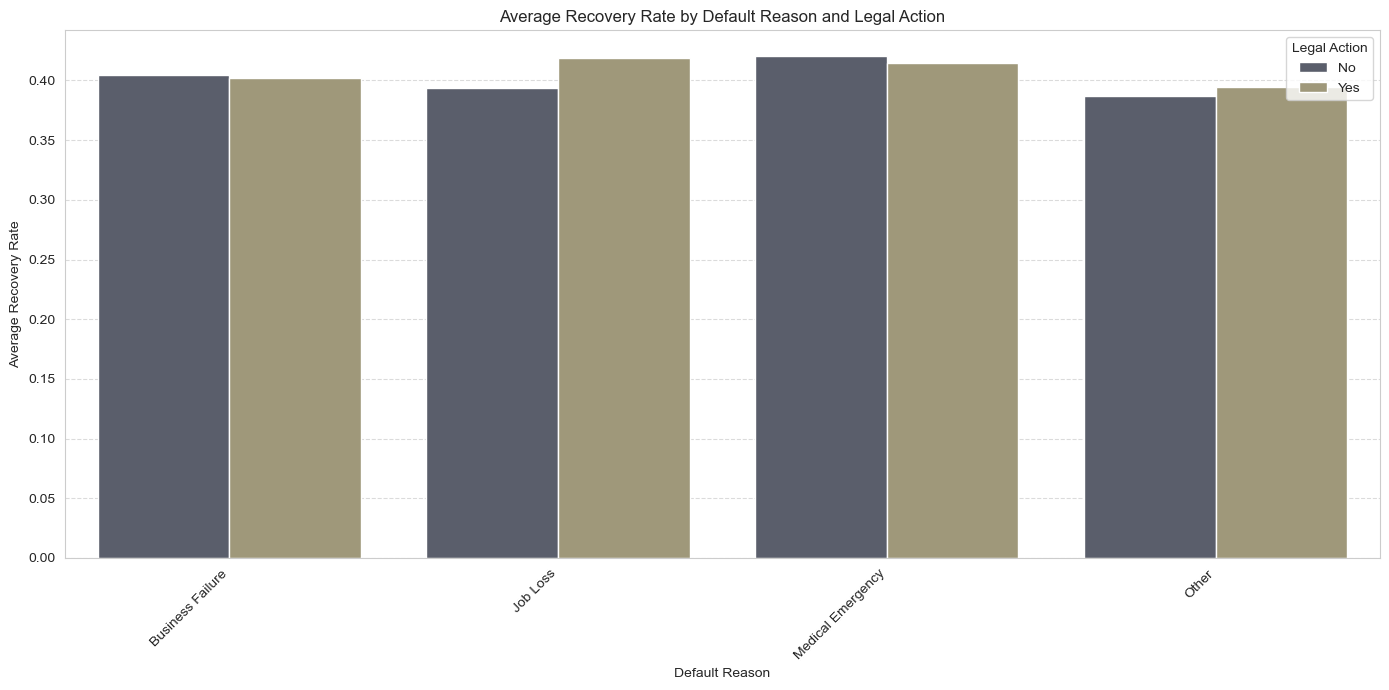

In [67]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Default_Reason', y='Recovery_Rate', hue='Legal_Action', data=recovery_by_reason_action, palette='cividis')
plt.title('Average Recovery Rate by Default Reason and Legal Action')
plt.xlabel('Default Reason')
plt.ylabel('Average Recovery Rate')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Legal Action')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 8. EMI Analysis
### Analyze the relationship between EMI amounts and default probabilities.
### Identify thresholds for EMI amounts where defaults are most likely.
### Compare EMI trends across loan types.


In [68]:
if 'Default_Flag' not in df_loans.columns:
    df_loans['Default_Flag'] = df_loans['Loan_ID'].isin(df_defaults['Loan_ID']).astype(int)

# Define EMI amount bins and labels
emi_bins = [0, 10000, 20000, 30000, 40000, 50000, 60000, np.inf] # Adjust bins as needed
emi_labels = ['0-10K', '10K-20K', '20K-30K', '30K-40K', '40K-50K', '50K-60K', '>60K']

# Create EMI_Group column
df_loans['EMI_Group'] = pd.cut(df_loans['EMI_Amount'], bins=emi_bins, labels=emi_labels, right=False)

# Calculate default count and total loans per EMI group
emi_default_analysis = df_loans.groupby('EMI_Group', observed=False)['Default_Flag'].agg(['sum', 'count']).reset_index()
emi_default_analysis.columns = ['EMI_Group', 'Defaults', 'Total_Loans']

# Calculate Default Probability
emi_default_analysis['Default_Probability'] = (emi_default_analysis['Defaults'] / emi_default_analysis['Total_Loans']) * 100

print('Default Probability by EMI Group:')
display(emi_default_analysis)

Default Probability by EMI Group:


,EMI_Group,Defaults,Total_Loans,Default_Probability
0,0-10K,702,7237,9.700152
1,10K-20K,850,9355,9.086050
2,20K-30K,906,9432,9.605598
3,30K-40K,821,9101,9.020987
4,40K-50K,849,9067,9.363626
5,50K-60K,902,9148,9.860079
6,>60K,3509,36660,9.571740


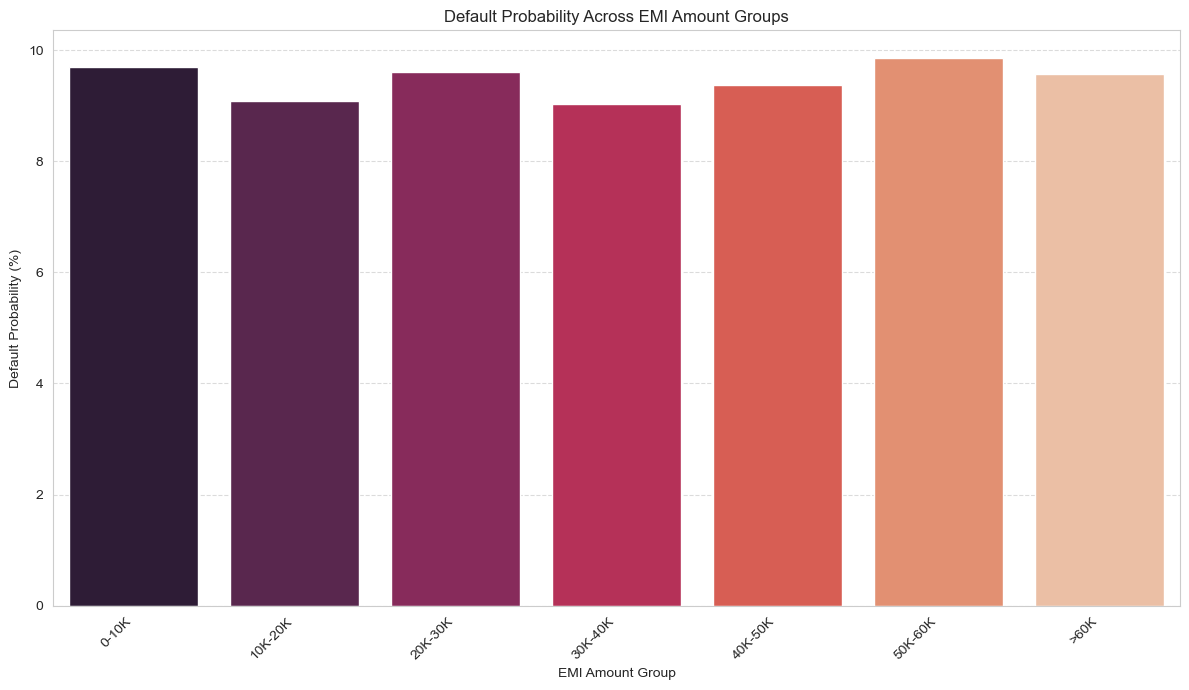

In [69]:
plt.figure(figsize=(12, 7))
sns.barplot(x='EMI_Group', y='Default_Probability', hue='EMI_Group', data=emi_default_analysis, palette='rocket', legend=False)
plt.title('Default Probability Across EMI Amount Groups')
plt.xlabel('EMI Amount Group')
plt.ylabel('Default Probability (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [70]:
# Merge df_loans with df_application to get Loan_Purpose for each loan
emi_loan_type_df = pd.merge(df_loans, df_application[['Loan_ID', 'Loan_Purpose']], on='Loan_ID', how='left')

# Display the head of the merged DataFrame to verify
print('Merged Loans and Application Data for EMI and Loan Type:')
display(emi_loan_type_df.head())

Merged Loans and Application Data for EMI and Loan Type:


,Loan_ID,Customer_ID,Loan_Amount,Interest_Rate,Loan_Term,Disbursal_Date,Repayment_Start_Date,Repayment_End_Date,Loan_Status,Overdue_Amount,EMI_Amount,Collateral_Details,Disbursal_Month_Year,Default_Flag,EMI_Group,Loan_Purpose
0,L000001,C045929,4030468,8.45,24,2023-03-25,2023-04-25,2025-03-25,Active,0,18668,Property,2023-03,0,10K-20K,Business
1,L000002,C038991,3498647,11.90,48,2023-10-23,2023-11-23,2027-10-23,Closed,44003,36012,Property,2023-10,0,30K-40K,Education
2,L000003,C046662,4871438,9.74,24,2024-07-30,2024-08-30,2026-07-30,Overdue,0,26347,NaN,2024-07,0,20K-30K,Business
3,L000004,C040268,541515,13.55,24,2024-11-22,2024-12-22,2026-11-22,Active,0,16106,NaN,2024-11,0,10K-20K,Home Renovation
4,L000005,C067057,631036,10.10,36,2024-03-30,2024-04-30,2027-03-30,Overdue,0,10127,NaN,2024-03,0,10K-20K,Education


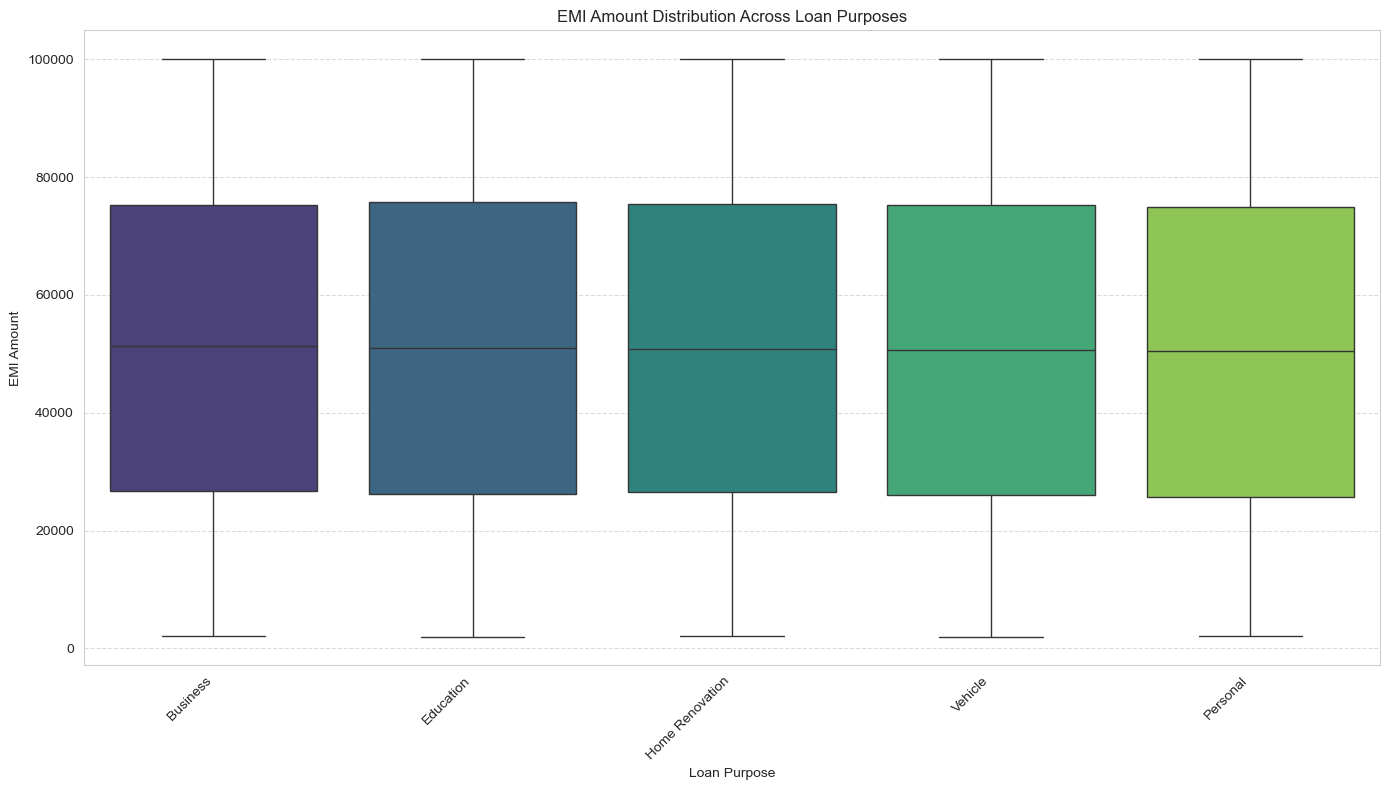

In [71]:
# Visualize EMI amount distribution across different loan purposes
plt.figure(figsize=(14, 8))
sns.boxplot(x='Loan_Purpose', y='EMI_Amount', data=emi_loan_type_df, palette='viridis', hue='Loan_Purpose', legend=False)
plt.title('EMI Amount Distribution Across Loan Purposes')
plt.xlabel('Loan Purpose')
plt.ylabel('EMI Amount')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 9. Loan Application Insights

### Calculate approval and rejection rates for loan applications.
### Identify the most common reasons for loan rejection.(The 'Rejection_Reason' column was previously dropped due to high missing values.)
### Compare application processing fees between approved and rejected applications.

In [72]:
# Calculate the total number of applications
total_applications = len(df_application)

# Count the number of approved and rejected applications
approval_counts = df_application['Approval_Status'].value_counts()

# Calculate approval and rejection rates
approval_rate = (approval_counts.get('Approved', 0) / total_applications) * 100
rejection_rate = (approval_counts.get('Rejected', 0) / total_applications) * 100

print(f"Total Applications: {total_applications}")
print(f"Number of Approved Applications: {approval_counts.get('Approved', 0)}")
print(f"Number of Rejected Applications: {approval_counts.get('Rejected', 0)}")
print(f"Approval Rate: {approval_rate:.2f}%")
print(f"Rejection Rate: {rejection_rate:.2f}%")

Total Applications: 82600
Number of Approved Applications: 70000
Number of Rejected Applications: 12600
Approval Rate: 84.75%
Rejection Rate: 15.25%


In [73]:
processing_fee_comparison = df_application.groupby('Approval_Status')['Processing_Fee'].describe()

print('Processing Fee Comparison between Approved and Rejected Applications:')
display(processing_fee_comparison)

Processing Fee Comparison between Approved and Rejected Applications:


,count,mean,std,min,25%,50%,75%,max
Approval_Status,,,,,,,,
Approved,70000.0,5252.395014,2741.573413,500.0,2895.0,5256.0,7626.0,10000.0
Rejected,12600.0,5255.141587,2721.010522,500.0,2897.5,5271.0,7602.0,9998.0


/var/folders/02/j6hqqdt54gn6z2k513lwgwsw0000gn/T/ipykernel_1720/1825737286.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Approval_Status', y='Processing_Fee', data=df_application, palette='coolwarm')


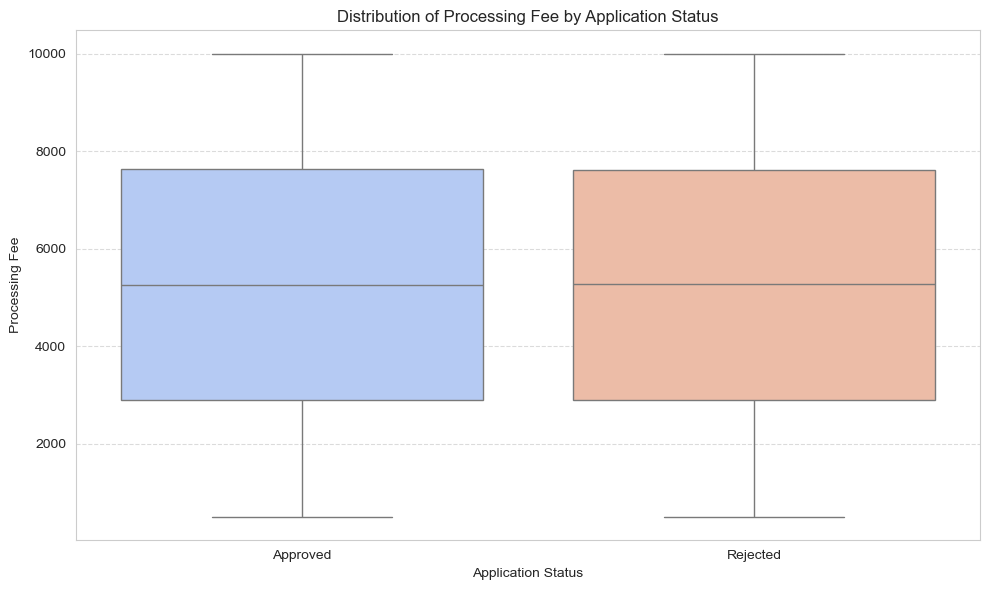

In [74]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Approval_Status', y='Processing_Fee', data=df_application, palette='coolwarm')
plt.title('Distribution of Processing Fee by Application Status')
plt.xlabel('Application Status')
plt.ylabel('Processing Fee')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()